<div style="background-color:#5A3516; color:#F3EEE6; padding:22px; border-radius:10px; border-left:8px solid #A8B7BA;">
<h1 style="color:#F3EEE6; margin-bottom:0;"><b>Machine Learning II — Customer Segmentation</b></h1>
<h3 style="color:#D8C0B4; margin-top:6px;">Notebook 3 — Clustering Modelling and Validation</h3>
</div>

<div style="background-color:#7E6A43; color:#F3EEE6; padding:15px; border-radius:10px;">
<b>Workflow overview.</b> This notebook develops the segmentation as a sequence of modelling decisions rather than as a single KMeans run. Alternative feature spaces, scalers and clustering families are compared first; the final solution is then validated through silhouette analysis, hierarchical benchmarks, density checks, topology based diagnostics and business profiling. The final labels are interpreted using the full customer profile, while the distance calculation is kept focused on the variables that best separate purchasing behaviour.
</div>


<div style="background-color:#5A3516; color:#F3EEE6; padding:18px; border-radius:10px; border-left:8px solid #A8B7BA;">
<h2 style="color:#F3EEE6; margin-top:0;"><b>Index</b></h2>
<ol>
<li>Imports and data loading</li>
<li>Outlier strategy check</li>
<li>Candidate feature sets and scalers</li>
<li>Diagnostics A - scaler comparison, elbow and dendrograms</li>
<li>Diagnostics B - feature set and k comparison</li>
<li>Model configuration</li>
<li>Model fitting and validation</li>
<li>Method benchmarks</li>
<li>Segment profiling</li>
<li>Reattach outliers and export</li>
<li>Final modelling conclusion</li>
</ol>
</div>


<div style="background-color:#5A3516; color:#F3EEE6; padding:20px; border-radius:10px; border-left:8px solid #A8B7BA;">
<h2 style="color:#F3EEE6; margin:0;"><b>1) Imports and data loading</b></h2>
</div>

In [1]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import silhouette_score

import utils_clustering as uc

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
pd.set_option("display.max_columns", None)

PROJECT_PALETTE = ['#B87540', '#B2543D', '#7E6A43', '#A8B7BA', '#D8C0B4', '#C8AB8C', '#5A3516', '#B98F70']
sns.set_theme(style='whitegrid', palette=PROJECT_PALETTE)

In [2]:
DATA_DIR = Path("../datasets")

regular = pd.read_csv(DATA_DIR / "info_clustering_unscaled.csv", index_col="customer_id")
outliers = pd.read_csv(DATA_DIR / "outlier_dataset.csv", index_col="customer_id")
raw_customer_info = pd.read_csv(DATA_DIR / "customer_info.csv")

print("Regular:", regular.shape, "| Outliers:", outliers.shape,
      "| Total:", len(regular) + len(outliers))
regular.head()


Regular: (32056, 39) | Outliers: (982, 39) | Total: 33038


,kids_home,teens_home,number_complaints,distinct_stores_visited,lifetime_spend_groceries,lifetime_spend_electronics,lifetime_spend_vegetables,lifetime_spend_nonalcohol_drinks,lifetime_spend_alcohol_drinks,lifetime_spend_meat,lifetime_spend_fish,lifetime_spend_hygiene,lifetime_spend_videogames,lifetime_spend_petfood,lifetime_total_distinct_products,percentage_of_products_bought_promotion,customer_loyalty_flag,latitude,longitude,typical_hour_sin,typical_hour_cos,customer_age,education_level,is_male,tenure,total_children,lifetime_spend_technology,log_total_spend,annual_spend_groceries,annual_spend_electronics,annual_spend_vegetables,annual_spend_nonalcohol_drinks,annual_spend_alcohol_drinks,annual_spend_meat,annual_spend_fish,annual_spend_hygiene,annual_spend_videogames,annual_spend_petfood,annual_spend_technology
customer_id,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
3,1,1,1,3,11731.0,4553.0,373.0,323.0,177.0,28.0,213.0,552.0,256.0,384.0,189,0.631599,1,38.794428,-9.215739,0.010342,-2.649291e-01,56.0,15,0,6,2,4809.0,10.060491,1955.166667,758.833333,62.166667,53.833333,29.500000,4.666667,35.500000,92.000000,42.666667,64.000000,801.500000
4,1,0,0,2,13694.0,963.0,2012.0,533.0,95.0,43.0,15.0,1880.0,333.0,665.0,130,0.149890,1,38.751711,-9.179611,0.193185,-8.810167e-01,50.0,15,0,13,1,1296.0,9.977203,1053.384615,74.076923,154.769231,41.000000,7.307692,3.307692,1.153846,144.615385,25.615385,51.153846,99.692308
5,0,0,0,2,12407.0,0.0,555.0,101.0,118.0,1265.0,273.0,507.0,101.0,222.0,81,0.069126,0,38.780678,-9.160656,0.258819,-9.659258e-01,54.0,17,1,21,0,101.0,9.658290,590.809524,0.000000,26.428571,4.809524,5.619048,60.238095,13.000000,24.142857,4.809524,10.571429,4.809524
7,0,0,2,1,7493.0,1105.0,84.0,757.0,1133.0,972.0,1083.0,485.0,1656.0,184.0,92,0.253609,1,38.739548,-9.148679,-1.000000,-1.665335e-16,43.0,12,1,5,0,2761.0,9.782111,1498.600000,221.000000,16.800000,151.400000,226.600000,194.400000,216.600000,97.000000,331.200000,36.800000,552.200000
8,0,0,3,1,9187.0,10841.0,380.0,592.0,718.0,1068.0,1015.0,297.0,1258.0,441.0,6,0.186569,1,38.733071,-9.188188,-0.965926,-2.588190e-01,56.0,12,1,5,0,12099.0,10.542627,1837.400000,2168.200000,76.000000,118.400000,143.600000,213.600000,203.000000,59.400000,251.600000,88.200000,2419.800000


<div style="background-color:#7E6A43; color:#F3EEE6; padding:15px; border-radius:10px;">
<b>Dataset reading decision.</b><br><br>
The clustering stage starts from the cleaned datasets produced in preprocessing. The regular customer base is used to learn the segment centres, while the separated outlier file is kept for the final assignment stage. This keeps the modelling step focused on the typical structure of the customer base without losing customers from the final deliverable.
</div>

In [3]:
print('Technology split available:',
      [c for c in ['lifetime_spend_electronics', 'lifetime_spend_videogames'] if c in regular.columns])

Technology split available: ['lifetime_spend_electronics', 'lifetime_spend_videogames']


<div style="background-color:#5A3516; color:#F3EEE6; padding:20px; border-radius:10px; border-left:8px solid #A8B7BA;">
<h2 style="color:#F3EEE6; margin:0;"><b>2) Outlier strategy check - separation vs IQR capping</b></h2>
<p style="color:#D8C0B4; margin:6px 0 0 0;">The preprocessing notebook exports two clustering inputs: <code>info_clustering_unscaled.csv</code> (outlier separation + reattachment) and <code>info_clustering_capped.csv</code> (IQR capping on the full dataset, all customers kept). This section fits the same KMeans configuration on both inputs and compares the results across silhouette, cluster balance and visual separation.</p>
</div>

<div style="background-color:#7E6A43; color:#F3EEE6; padding:15px; border-radius:10px;">
<b>Why the outlier check appears before the model search.</b><br><br>
Outlier handling affects every distance based model, so it is reviewed before choosing the final feature set. The comparison is not a separate modelling objective; it is a quality check that verifies whether the preprocessing decision produces a cleaner and more interpretable segmentation.
</div>

<div style="background-color:#7E6A43; color:#F3EEE6; padding:15px; border-radius:10px;">
<b>Why this comparison matters.</b><br><br>
Both strategies address the same problem: extreme customers distort cluster centroids. Separation removes them entirely and reattaches via nearest centroid; capping clips their values and keeps them in the model fit. Each choice involves a trade-off:<br><br>
— <b>Separation</b> keeps centroid positions clean and interpretable, but the reattachment of outliers to a nearest-neighbour centroid is an approximation.<br>
— <b>Capping</b> keeps all customers in the fit, but changes the actual spend values of extreme customers, which can blur high-value segment boundaries.<br><br>
The comparison below makes this trade-off explicit with quantitative evidence rather than assuming one strategy is always better.
</div>

In [4]:
capped = pd.read_csv(DATA_DIR / 'info_clustering_capped.csv', index_col='customer_id')
print('Capped dataset loaded:', capped.shape)

Capped dataset loaded: (33038, 35)


In [5]:
_COMPARE_FEATURE_SET = "spend + promo no groceries"
_COMPARE_K = 8
_COMPARE_SCALER = "MinMax"
_COMPARE_LOGABS = False
_candidate_sets = uc.build_candidate_feature_sets(regular)
_distance_cols, _logabs = _candidate_sets[_COMPARE_FEATURE_SET]
strategy_comparison = uc.compare_outlier_strategies(
    separation_df=regular,
    capped_df=capped,
    feature_cols=_distance_cols,
    k=_COMPARE_K,
    scaler_name=_COMPARE_SCALER,
    logabs=_COMPARE_LOGABS,
    random_state=0,
)
display(strategy_comparison)

,strategy,n_customers,k,scaler,silhouette,negative_silhouette_pct,min_cluster_pct,max_cluster_pct
0,Separation (regular only),32056,8,MinMax,0.2491,2.58,9.40,19.63
1,IQR capping (full dataset),33038,8,MinMax,0.2574,4.09,10.15,18.82


### 2.1 - UMAP side by side

The UMAP projections below use the same feature set and scaler for both strategies. Visual cluster separation under capping can differ from separation because the capped dataset includes all customers and their extreme values are compressed toward the fence.

OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


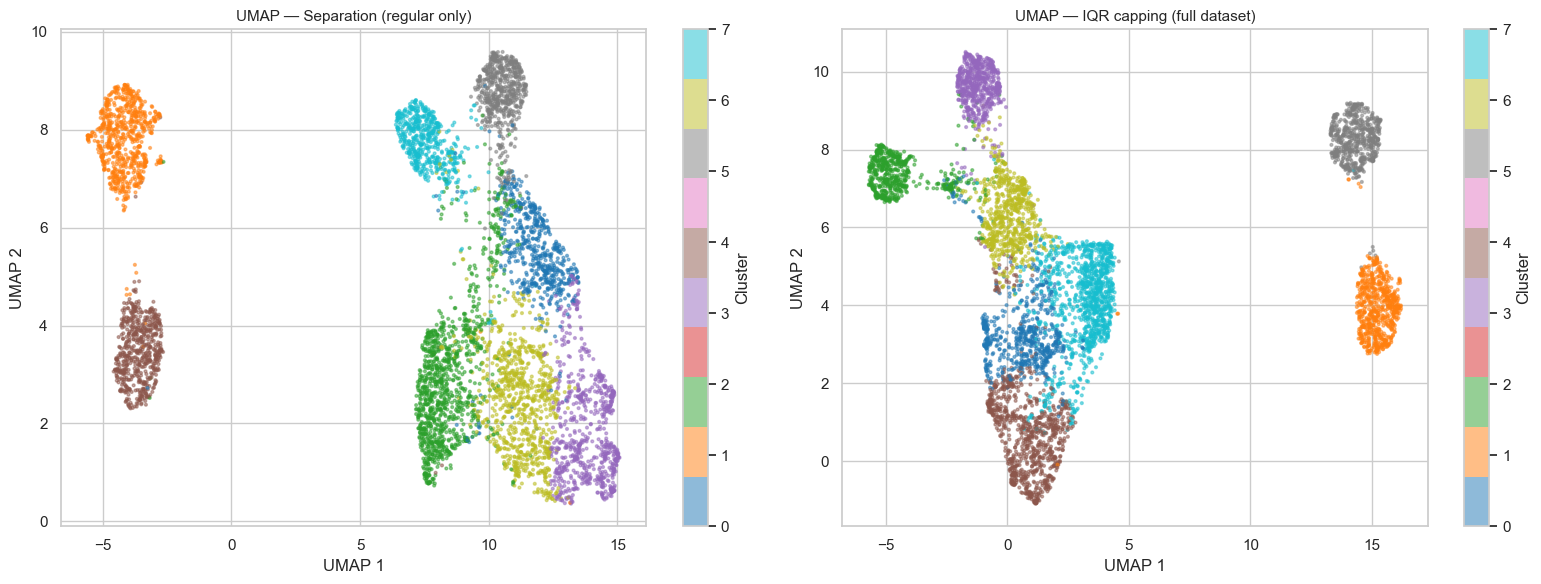

In [6]:
uc.plot_strategy_umap_comparison(
    separation_df=regular,
    capped_df=capped,
    feature_cols=_distance_cols,
    k=_COMPARE_K,
    scaler_name=_COMPARE_SCALER,
    logabs=_COMPARE_LOGABS,
    random_state=0,
)

<div style="background-color:#7E6A43; color:#F3EEE6; padding:15px; border-radius:10px;">
<b>Strategy selection.</b><br><br>
The separation strategy is preferred when the silhouette and UMAP show cleaner cluster boundaries, because centroids are fitted on a homogeneous customer population. The capping strategy is preferred when the two solutions are comparable on all metrics, since it avoids the two-step pipeline and assigns every customer through the same fitting process.<br><br>
The final choice is documented in the modelling conclusion below.
</div>

<div style="background-color:#5A3516; color:#F3EEE6; padding:20px; border-radius:10px; border-left:8px solid #A8B7BA;">
<h2 style="color:#F3EEE6; margin:0;"><b>3) Candidate feature sets and scalers</b></h2>
<p style="color:#D8C0B4; margin:6px 0 0 0;">This section defines the modelling search space. The comparison separates absolute spend, transformed spend, promotion behaviour and optional demographic or engagement variables, so that the final feature set can be justified with evidence rather than selected manually.</p>
</div>


<div style="background-color:#7E6A43; color:#F3EEE6; padding:15px; border-radius:10px;">
<b>Feature set principle.</b><br><br>
The feature search is intentionally conservative. Variables are included in the clustering distance only when they help separate purchasing behaviour. Broader descriptors such as age, loyalty, children, complaints and geography are still important, but they are more appropriate for profiling because they help explain the segments after the mathematical groups have been formed.
</div>

<div style="background-color:#7E6A43; color:#F3EEE6; padding:15px; border-radius:10px;">
Some variables describe related information. Absolute category spend is used for the clustering distance, while broader summaries such as <code>log_total_spend</code>, demographics, geography and loyalty variables are reserved for profiling. This avoids giving duplicated weight to the same behaviour while still allowing the interpretation stage to use the full customer profile.
</div>


In [7]:
candidate_sets = uc.build_candidate_feature_sets(regular)
for name, (cols, logabs) in candidate_sets.items():
    print(f'{name:32s} | {len(cols):2d} cols | log_abs_spend={logabs}')

scaler_options = ['Standard', 'MinMax', 'Robust', 'None']
print('\nScalers available:', scaler_options)

lifetime_spend                   |  9 cols | log_abs_spend=False
lifetime_spend no groceries      |  8 cols | log_abs_spend=False
log_lifetime_spend               |  9 cols | log_abs_spend=True
log_lifetime_spend no groceries  |  8 cols | log_abs_spend=True
spend + promo                    | 10 cols | log_abs_spend=False
spend + promo no groceries       |  9 cols | log_abs_spend=False
log_spend + promo                | 10 cols | log_abs_spend=True
log_spend + promo no groceries   |  9 cols | log_abs_spend=True
shares no groceries              |  1 cols | log_abs_spend=False
log_spend + demo                 | 12 cols | log_abs_spend=True
log_spend + demo no groceries    | 11 cols | log_abs_spend=True
log_spend + engagement + demo    | 18 cols | log_abs_spend=True
log_spend + engagement + demo no groceries | 17 cols | log_abs_spend=True
spend + promo granular tech      | 10 cols | log_abs_spend=False
annual_spend                     | 11 cols | log_abs_spend=False
annual_spend no groceri

<div style="background-color:#5A3516; color:#F3EEE6; padding:20px; border-radius:10px; border-left:8px solid #A8B7BA;">
<h2 style="color:#F3EEE6; margin:0;"><b>4) Diagnostics A - scaler comparison, elbow and dendrograms</b></h2>
<p style="color:#D8C0B4; margin:6px 0 0 0;">This block checks whether the selected structure depends strongly on preprocessing choices. Scaler comparison evaluates distance sensitivity, the elbow checks compactness gains, and the dendrograms inspect whether hierarchical structure is visible under several linkage rules.</p>
</div>


### 4.1 - Scaler comparison (silhouette vs k)

In [8]:
INSPECT_SET = "spend + promo no groceries"  
INSPECT_SCALER = "MinMax"  

inspect_cols, inspect_logabs = candidate_sets[INSPECT_SET]
print(f'Inspecting: {INSPECT_SET}  ({len(inspect_cols)} cols, log_abs={inspect_logabs})')
print(f'Inspection scaler: {INSPECT_SCALER}')


Inspecting: spend + promo no groceries  (9 cols, log_abs=False)
Inspection scaler: MinMax


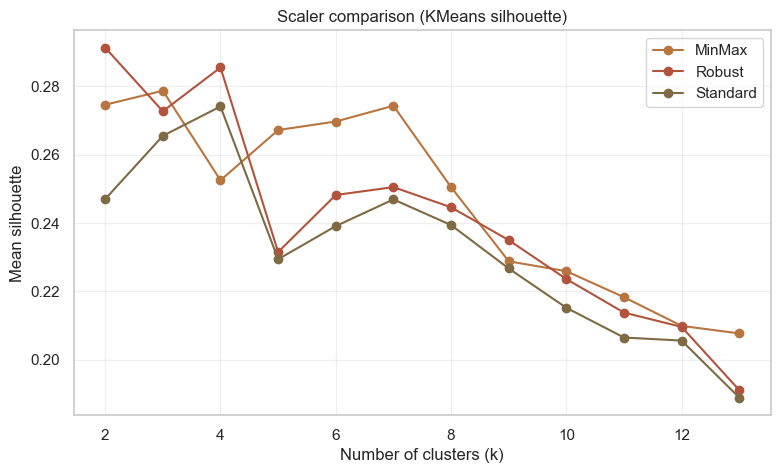

scaler,MinMax,Robust,Standard
k,,,
2,0.2746,0.2913,0.2470
3,0.2787,0.2727,0.2655
4,0.2525,0.2855,0.2741
5,0.2672,0.2315,0.2294
6,0.2697,0.2482,0.2391
7,0.2743,0.2505,0.2469
8,0.2505,0.2446,0.2394
9,0.2288,0.2350,0.2267
10,0.2259,0.2236,0.2152


In [9]:
scaler_scores = uc.compare_scalers(regular, inspect_cols, k_range=range(2, 14))
uc.plot_scaler_comparison(scaler_scores)
scaler_scores.pivot(index='k', columns='scaler', values='silhouette')

<div style="background-color:#7E6A43; color:#F3EEE6; padding:15px; border-radius:10px;">
<b>Scaler selection interpretation.</b><br><br>
Both RobustScaler and MinMaxScaler were considered because the spend variables are skewed and measured on different scales. RobustScaler is usually safer when extreme observations remain in the modelling set, since it reduces the influence of unusually high values. However, in this project the most extreme customers are already held aside as outliers before fitting the final centroids. Under this cleaner modelling set, MinMaxScaler becomes a strong option because it places all clustering variables on the same 0-1 range while preserving their relative ordering.<br><br>
For the selected feature set and final <i>k = 8</i> configuration, MinMaxScaler kept the clusters cleaner and more interpretable than the alternatives tested. The resulting clusters still correspond to clear business groups. Therefore, MinMaxScaler is selected for the final model because it improves geometric separation without sacrificing interpretability.
</div>


<div style="background-color:#7E6A43; color:#F3EEE6; padding:15px; border-radius:10px;">
<b>A note on groceries.</b> Groceries are kept in the dataset for profiling because they are behaviourally important. However, groceries can dominate the distance calculation because most customers spend heavily there. For this reason, the candidate grid includes versions with and without <code>lifetime_spend_groceries</code>. If the without groceries option gives clearer personas, use it for KMeans and still use groceries afterwards to describe the segments.
</div>


### 4.2 - Inertia elbow

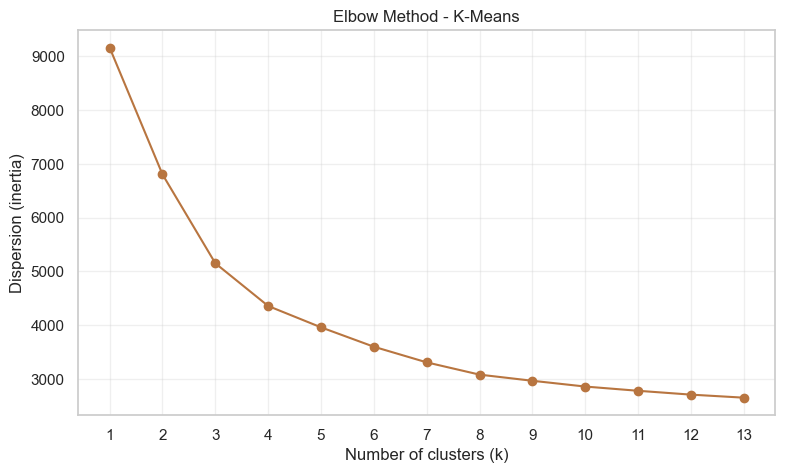

In [10]:
X_inspect = uc.apply_feature_pipeline(regular, inspect_cols, inspect_logabs,
                                      uc.get_scaler(INSPECT_SCALER), fit=True)
k_values, inertia = uc.kmeans_elbow(X_inspect, range(1, 14))
uc.plot_elbow(k_values, inertia)

### 4.3 - Ward dendrogram (on a sample)

<div style="background-color:#7E6A43; color:#F3EEE6; padding:15px; border-radius:10px;">
Agglomerative clustering is O(n²) in memory, so we draw the dendrogram on a random sample. Reading where long vertical links get cut suggests candidate values of k.
</div>

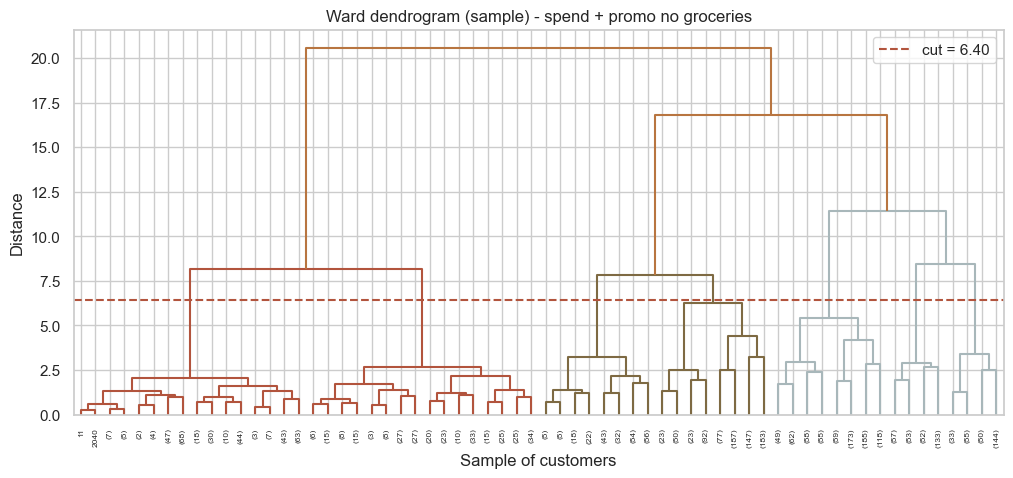

In [11]:
DENDRO_CUT_HEIGHT = 6.4

uc.plot_sample_dendrogram(
    X_inspect,
    title=f"Ward dendrogram (sample) - {INSPECT_SET}",
    linkage="ward",
    sample_size=3000,
    cut_height=DENDRO_CUT_HEIGHT,
    random_state=0,
)

<div style="background-color:#7E6A43; color:#F3EEE6; padding:15px; border-radius:10px;">
<b>Ward dendrogram interpretation.</b><br><br>
The Ward dendrogram is used as a visual diagnostic for compact, variance minimising group structure. Long vertical jumps indicate that relatively distant groups are being merged, so possible cut points should be considered just before those large jumps. In this dataset, the dendrogram suggests that there is meaningful hierarchical structure, but it does not provide a single unambiguous cut. Several values of <i>k</i> remain plausible, which is why the final number of clusters is not chosen from the dendrogram alone.<br><br>
Ward is nevertheless useful because it is conceptually aligned with KMeans: both favour compact groups under Euclidean geometry. Therefore, if Ward shows a broadly coherent structure, it supports the use of a based on centroids final model.
</div>


### 4.4 - Complete, average and single linkage dendrograms

Ward is usually the most compatible linkage with KMeans because both favour compact groups. Complete, average and single linkage are added as sensitivity checks: complete tends to form tighter clusters, average provides an intermediate linkage criterion, and single can reveal chaining/noise effects.


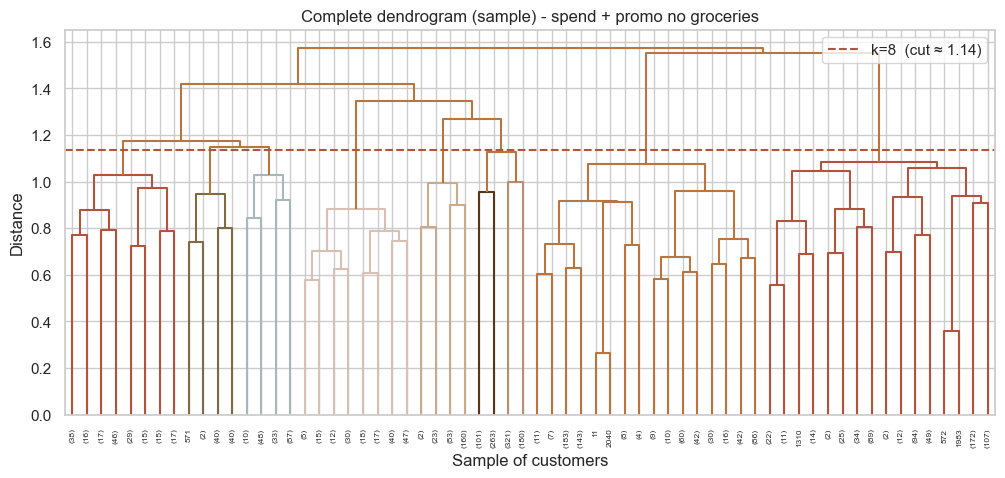

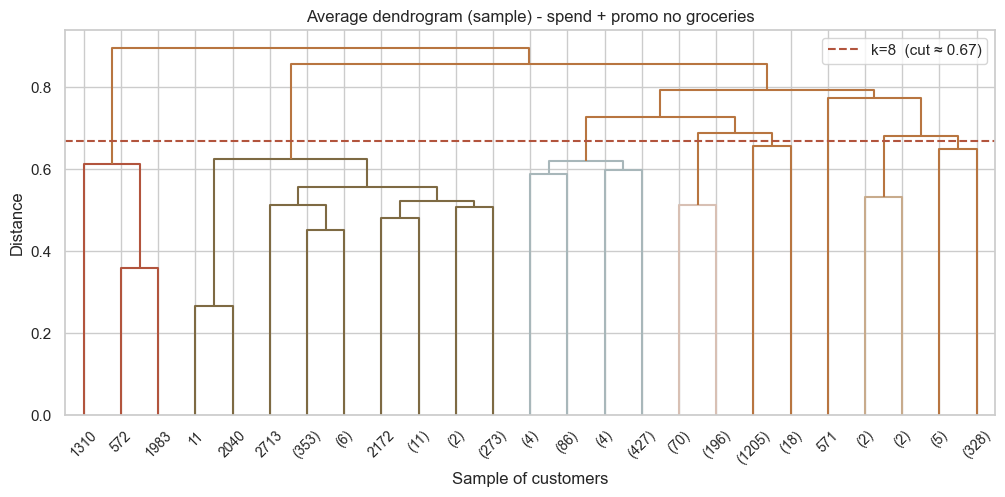

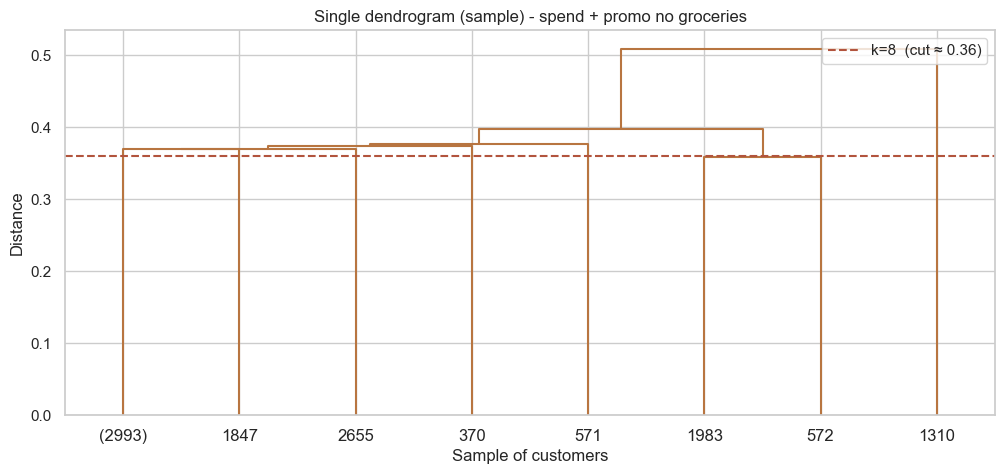

In [13]:
uc.plot_alternative_dendrograms(
    X_inspect,
    title_suffix=INSPECT_SET,
    k=8,
    sample_size=3000,
    random_state=0,
)


<div style="background-color:#7E6A43; color:#F3EEE6; padding:15px; border-radius:10px;">
<b>Linkage comparison interpretation.</b><br><br>
The complete, average and single dendrograms are interpreted as sensitivity checks rather than competing final models.
<br><br>
<b>Complete linkage</b> tends to form compact and conservative clusters because it merges groups according to their farthest pairwise distance. If complete linkage shows large jumps, it suggests that some compact groups are clearly separated from the rest of the data.
<br><br>
<b>Average linkage</b> is less strict and merges clusters based on average distances between observations. It is useful as an intermediate check: when average linkage broadly agrees with Ward or complete linkage, the hierarchical structure is less dependent on one specific linkage rule.
<br><br>
<b>Single linkage</b> is the most sensitive to chaining effects, because clusters can be joined through narrow bridges of similar observations. If single linkage produces elongated chains or less clear cuts, this does not necessarily invalidate the segmentation; it indicates that some customers lie on behavioural gradients rather than in perfectly isolated groups.
<br><br>
Overall, the dendrograms support the idea that the data contains structure, but the cut point remains partly subjective. For this reason, the final solution is selected using the dendrograms together with silhouette, scaler comparison, method benchmarks and profiling interpretability.
</div>


<div style="background-color:#5A3516; color:#F3EEE6; padding:20px; border-radius:10px; border-left:8px solid #A8B7BA;">
<h2 style="color:#F3EEE6; margin:0;"><b>5) Diagnostics B - feature set and k silhouette grid</b></h2>
<p style="color:#D8C0B4; margin:6px 0 0 0;">After selecting the scaler and inspecting hierarchical structure, the silhouette grid is used to compare candidate feature spaces across several values of <i>k</i>. This provides a broader check that the final configuration is not chosen from a single diagnostic only.</p>
</div>


<div style="background-color:#7E6A43; color:#F3EEE6; padding:15px; border-radius:10px;">
<b>How k is treated in this notebook.</b><br><br>
The number of clusters is not fixed before the diagnostic stage. Values between 6 and 10 are compared because this range is large enough to reveal smaller customer groups, but still small enough to keep the final segmentation understandable. The selected value must therefore satisfy three conditions: acceptable separation, readable segment sizes and distinct business profiles.
</div>

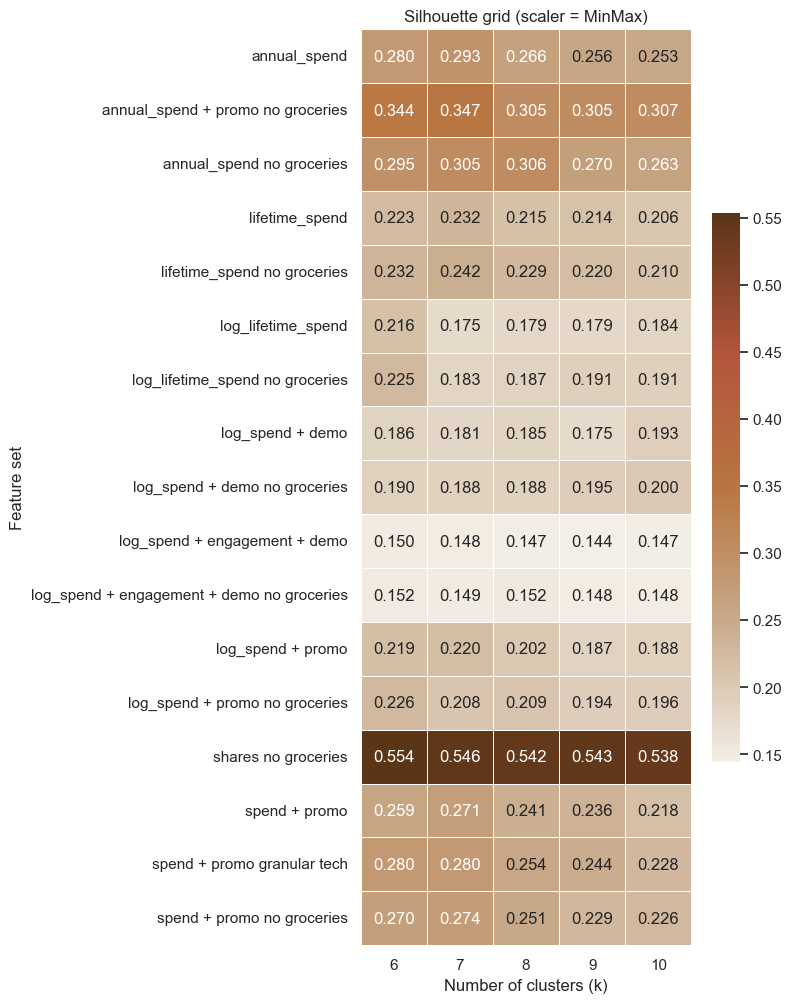

k,6,7,8,9,10
feature_set,,,,,
annual_spend,0.2804,0.2927,0.2658,0.2562,0.2525
annual_spend + promo no groceries,0.3438,0.3466,0.3054,0.3055,0.3071
annual_spend no groceries,0.2948,0.3048,0.3058,0.2696,0.2633
lifetime_spend,0.2228,0.2316,0.2154,0.2140,0.2060
lifetime_spend no groceries,0.2323,0.2419,0.2288,0.2196,0.2101
log_lifetime_spend,0.2160,0.1753,0.1789,0.1788,0.1838
log_lifetime_spend no groceries,0.2253,0.1829,0.1867,0.1913,0.1913
log_spend + demo,0.1861,0.1813,0.1846,0.1746,0.1930
log_spend + demo no groceries,0.1904,0.1883,0.1880,0.1950,0.2002


In [14]:
grid = uc.silhouette_grid(regular, candidate_sets, k_range=range(6, 11),
                          scaler_name='MinMax')
grid_pivot = uc.plot_silhouette_grid(grid, title='Silhouette grid (scaler = MinMax)')
grid_pivot

<div style="background-color:#7E6A43; color:#F3EEE6; padding:15px; border-radius:10px;">
<b>Interpretation.</b> Higher silhouette values indicate more compact and separated clusters for each candidate feature space. However, model selection also considers scaler behaviour, dendrogram structure, cluster size balance and business interpretability, since a mathematically strong solution is not necessarily the most useful segmentation.
</div>

<div style="background-color:#8F4A34; color:#F3EEE6; padding:20px; border-radius:10px; border-left:8px solid #B2543D;">
<h2 style="color:#F3EEE6; margin:0;"><b>6) Model configuration</b></h2>
<p style="color:#D8C0B4; margin:6px 0 0 0;">The final configuration is chosen after the diagnostic stage. The objective is not to maximise one metric in isolation, but to select a solution that is quantitatively acceptable, balanced and interpretable from a customer segmentation perspective.</p>
</div>


<div style="background-color:#7E6A43; color:#F3EEE6; padding:15px; border-radius:10px;">
<b>Why a slightly lower metric can still be the better model.</b><br><br>
Silhouette is useful, but it is not the only criterion in customer segmentation. A model with a marginally higher silhouette can still be weaker if it merges useful personas, creates one dominant generic group or produces labels that cannot be explained with the customer profile. The final configuration is therefore selected as a balance between validation metrics and business interpretation.
</div>

In [15]:
FEATURE_SET = "spend + promo no groceries"
SCALER      = "MinMax"  
K           = 8  


In [16]:
distance_cols, LOGABS = candidate_sets[FEATURE_SET]
profiling_cols = uc.get_profiling_features(regular, distance_cols)
scaler = uc.get_scaler(SCALER)
X = uc.apply_feature_pipeline(regular, distance_cols, LOGABS, scaler, fit=True)

print(f'Feature set : {FEATURE_SET}  ({len(distance_cols)} cols, log_abs={LOGABS})')
print(f'Scaler      : {SCALER}')
print(f'k           : {K}')
print(f'Matrix      : {X.shape}')

Feature set : spend + promo no groceries  (9 cols, log_abs=False)
Scaler      : MinMax
k           : 8
Matrix      : (32056, 9)


<div style="background-color:#7E6A43; color:#F3EEE6; padding:15px; border-radius:10px;">
<b>Why the model is trained on the regular base.</b><br><br>
The clustering model is fitted on the regular customer dataset exported by preprocessing. The separated outliers are not discarded; they are kept aside and assigned after the centroids are learned. This keeps the KMeans centres from being pulled toward extreme customers, while still ensuring that every customer receives a final segment label.
</div>


<div style="background-color:#7E6A43; color:#F3EEE6; padding:15px; border-radius:10px;">
<b>Decision log.</b><br><br>
The selected model uses <i>spend + promo no groceries</i>, <i>MinMaxScaler</i> and <i>k = 8</i>. This choice was made after comparing several feature blocks, scalers and values of <i>k</i>, rather than by relying on one diagnostic only.<br><br>
Groceries were excluded from the clustering distance because they behaved as a dominant baseline category. When groceries were included, several segments became grocery driven and harder to distinguish from each other. The variable is still kept for profiling, where it is useful to identify loyal and high value customers.<br><br>
MinMax scaling was selected for the current model because the most extreme customers had already been separated during preprocessing. In the remaining regular customer base, MinMax scaling keeps the spending variables and the promotion percentage on a comparable range without changing the original ordering of customers.<br><br>
The final value of <i>k = 8</i> was chosen as a balance between geometric validation and business interpretation. A smaller solution merged behaviours that were easier to explain separately, while larger solutions added complexity without a clear gain in segment meaning. The eight cluster solution gives a readable set of profiles: Loyalists, Vegetarians, Regulars, Promoters, Wellness, Families, Economizers and Techies.
</div>


<div style="background-color:#5A3516; color:#F3EEE6; padding:20px; border-radius:10px; border-left:8px solid #A8B7BA;">
<h2 style="color:#F3EEE6; margin:0;"><b>7) Model fitting and validation</b></h2>
<p style="color:#D8C0B4; margin:6px 0 0 0;">KMeans is fitted using the selected configuration. The solution is then validated through cluster size distribution, silhouette analysis and two dimensional PCA/UMAP projections.</p>
</div>

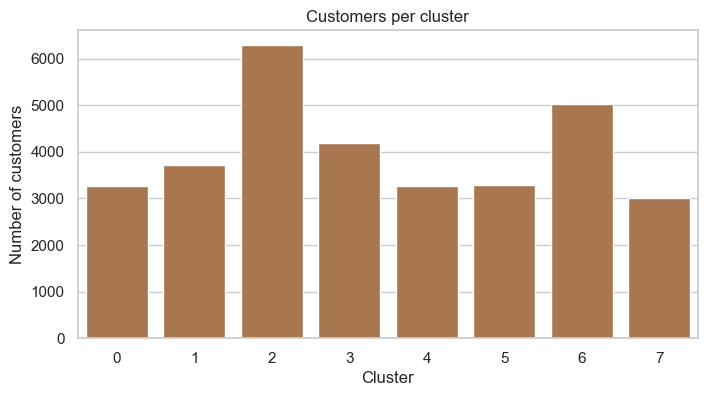

,customers,share_%
cluster,,
0,3261,10.2
1,3715,11.6
2,6293,19.6
3,4197,13.1
4,3264,10.2
5,3288,10.3
6,5024,15.7
7,3014,9.4


In [17]:
kmeans = uc.fit_kmeans(X, K)
regular['cluster'] = kmeans.labels_
uc.plot_cluster_sizes(regular, 'cluster')
uc.cluster_sizes(regular, 'cluster')

### 7.1 - Silhouette plot

<div style="background-color:#7E6A43; color:#F3EEE6; padding:15px; border-radius:10px;">
<b>How the validation plots are interpreted.</b><br><br>
The silhouette plot is used to check whether the clusters are compact in the original modelling space. The two dimensional projections are used only as visual support, because UMAP and t-SNE can change distances when reducing many variables to two axes. A convincing solution should therefore be reasonable in both views, not only visually attractive in the map.
</div>

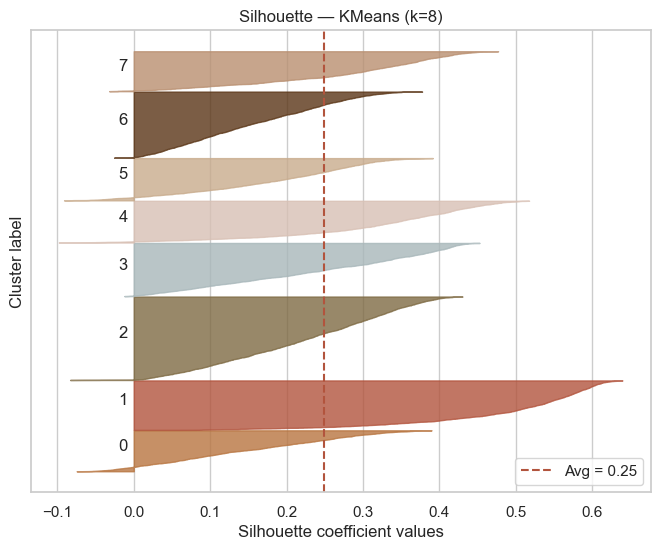

Average silhouette: 0.249


In [18]:
avg_sil = uc.plot_silhouette_blades(X, kmeans.labels_, title=f'Silhouette — KMeans (k={K})')
print('Average silhouette:', round(avg_sil, 3))

### 7.2 - PCA, UMAP and t-SNE projections

<div style="background-color:#7E6A43; color:#F3EEE6; padding:15px; border-radius:10px;">
PCA, UMAP and t-SNE are used as two dimensional projections for visual inspection. PCA gives a linear baseline view, UMAP checks both local neighbourhoods and broader structure, and t-SNE is added as a complementary local neighbourhood check. These plots are not used alone to choose the final number of clusters; they support the interpretation of the selected solution.
</div>

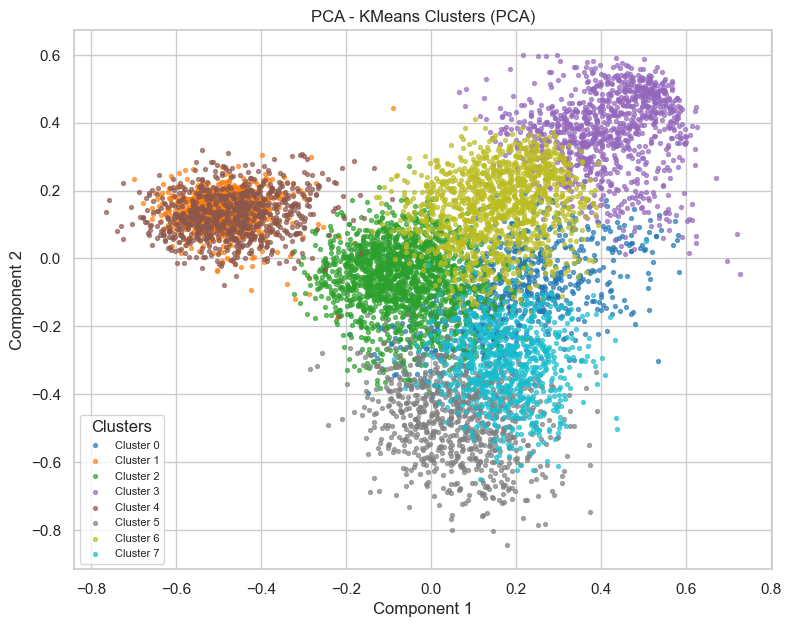

In [19]:
X_emb, lab_emb = uc.subsample(X, kmeans.labels_, n=8000)
pca_emb = uc.embed_pca(X_emb)
uc.plot_embedding(pca_emb, lab_emb, title='PCA - KMeans Clusters', method_name='PCA')

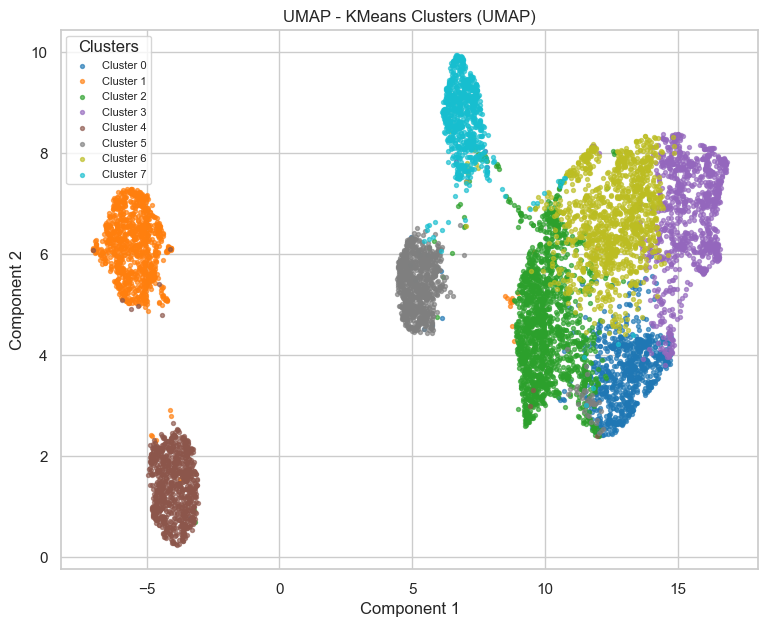

In [20]:
umap_emb, method = uc.embed_umap(X_emb)
uc.plot_embedding(umap_emb, lab_emb, title='UMAP - KMeans Clusters', method_name=method)

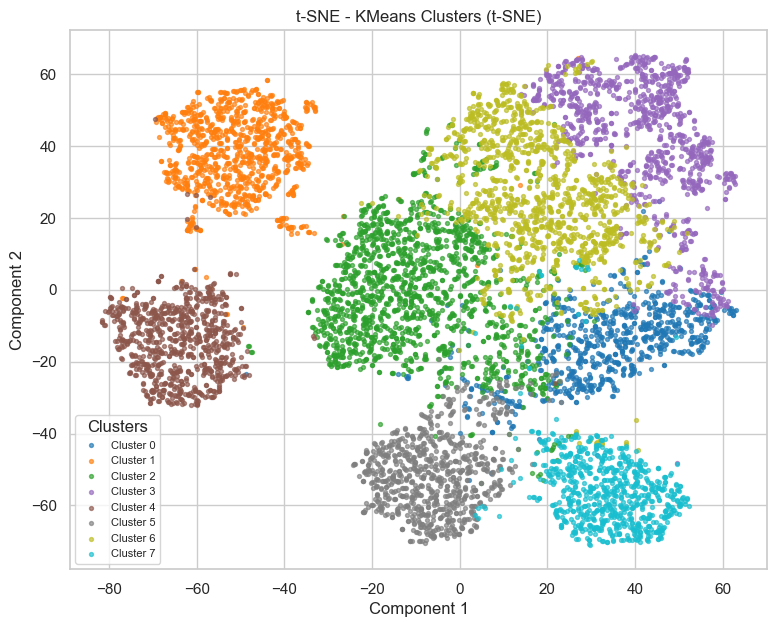

In [21]:
tsne_emb = uc.embed_tsne(X_emb, perplexity=30, random_state=0)
uc.plot_embedding(tsne_emb, lab_emb, title='t-SNE - KMeans Clusters', method_name='t-SNE')

<div style="background-color:#7E6A43; color:#F3EEE6; padding:15px; border-radius:10px;">
t-SNE is interpreted only as a complementary visual check. It is useful for seeing whether nearby customers tend to receive similar labels, but it can distort global distances. For this reason, the final decision remains based on silhouette, UMAP, cluster balance, method benchmarks and business profiling.
</div>

### 7.3 - Current solution and petfood alternative

<div style="background-color:#7E6A43; color:#F3EEE6; padding:15px; border-radius:10px;">
A second candidate model was tested because petfood appeared as a possible business segment during profiling. This alternative adds <code>lifetime_spend_petfood</code> to the distance space and separates electronics from videogames. The purpose is not to force a pet segment, but to check whether this behaviour is strong enough to justify a different final model.<br><br>
The comparison below therefore reads both candidates in the same way: silhouette, negative silhouettes, cluster balance and interpretability. The current model remains the preferred final export if it gives the cleaner structure; the petfood model is kept only if the additional business value compensates for any loss in geometric quality.
</div>


<div style="background-color:#7E6A43; color:#F3EEE6; padding:15px; border-radius:10px;">
<b>Purpose of the alternative model.</b><br><br>
The petfood alternative is included because it answers a practical question raised during profiling: whether pet related behaviour is strong enough to become a final segment. This check strengthens the final choice, because the rejected alternative is documented instead of ignored.
</div>

In [22]:
petfood_features = [
    "lifetime_spend_electronics",
    "lifetime_spend_videogames",
    "lifetime_spend_vegetables",
    "lifetime_spend_hygiene",
    "lifetime_spend_petfood",
    "percentage_of_products_bought_promotion",
    "lifetime_spend_meat",
    "lifetime_spend_fish",
]

pet_model, X_pet, pet_labels, pet_scaler, pet_metrics = uc.fit_kmeans_solution(
    regular,
    petfood_features,
    k=8,
    scaler_name=SCALER,
    iqr_k=None,
    random_state=42,
    n_init=30,
)

current_metrics = uc.clustering_metrics(X, kmeans.labels_, random_state=42)
current_metrics.update({
    "solution": "Final candidate",
    "feature_logic": FEATURE_SET,
    "scaler": SCALER,
    "iqr_k": None,
    "n_features": len(distance_cols),
})

pet_metrics.update({
    "solution": "Petfood check",
    "feature_logic": "granular spend with petfood",
})

comparison = pd.DataFrame([current_metrics, pet_metrics])[
    ["solution", "feature_logic", "n_features", "scaler", "iqr_k",
     "silhouette", "negative_silhouette_pct", "min_cluster_pct", "max_cluster_pct"]
]
comparison


,solution,feature_logic,n_features,scaler,iqr_k,silhouette,negative_silhouette_pct,min_cluster_pct,max_cluster_pct
0,Final candidate,spend + promo no groceries,9,MinMax,None,0.2511,2.82,9.40,19.63
1,Petfood check,granular spend with petfood,8,MinMax,None,0.2643,3.38,8.63,20.46


<div style="background-color:#7E6A43; color:#F3EEE6; padding:15px; border-radius:10px;">
<b>How to read the candidate comparison.</b><br><br>
This table is kept purely as a modelling check. The alternative includes petfood to test whether that behaviour improves the mathematical segmentation. Segment names are not assigned here, because naming belongs to the characterization notebook after the full profile has been reviewed.<br><br>
The final model is retained if it has the stronger overall balance between silhouette, negative silhouettes, cluster size distribution and visual structure.
</div>


### 7.4 - Petfood alternative validation plots

The silhouette plot and UMAP projection below are used to check whether the petfood alternative is reliable enough to replace the current model. The silhouette evaluates separation in the original clustering space, while UMAP gives a visual approximation of neighbourhood structure. A model can be visually appealing but weak in the original space, so both views are interpreted together.


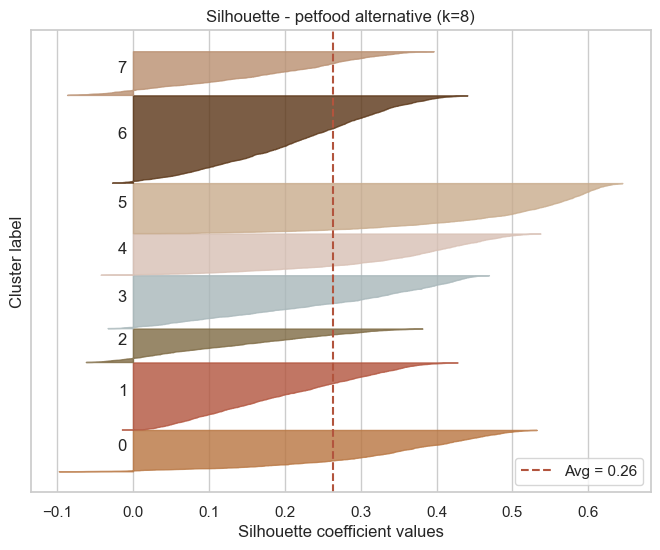

Average silhouette: 0.263


In [23]:
pet_avg_sil = uc.plot_silhouette_blades(
    X_pet,
    pet_labels,
    title="Silhouette - petfood alternative (k=8)",
)
print("Average silhouette:", round(pet_avg_sil, 3))


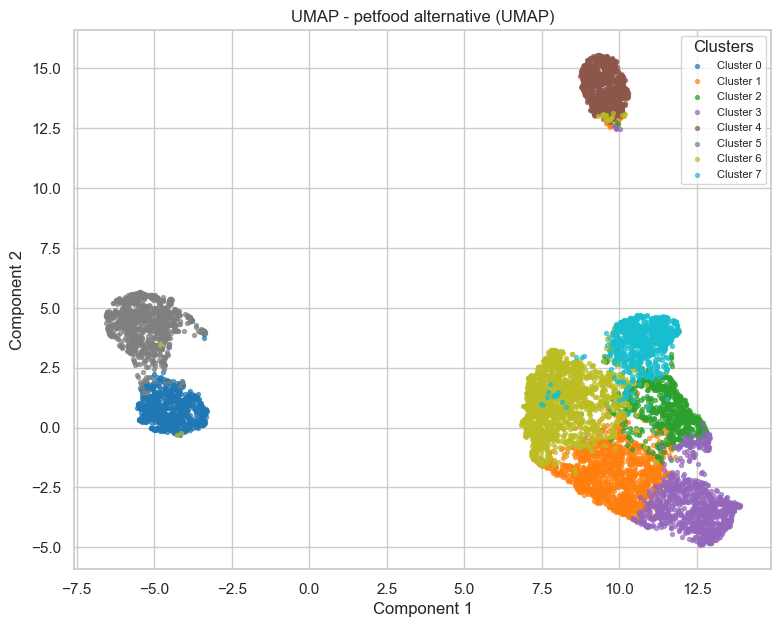

In [24]:
X_pet_emb, lab_pet_emb = uc.subsample(X_pet, pet_labels, n=8000, random_state=42)
pet_umap, pet_method = uc.embed_umap(X_pet_emb, random_state=42)
uc.plot_embedding(
    pet_umap,
    lab_pet_emb,
    title="UMAP - petfood alternative",
    method_name=pet_method,
)


<div style="background-color:#7E6A43; color:#F3EEE6; padding:15px; border-radius:10px;">
<b>Petfood alternative decision.</b><br><br>
The alternative confirms that a pet oriented segment can be obtained, but the overall structure is slightly less clean than the current model. Since the main objective is a robust segmentation that can be defended across several diagnostics, petfood is not used in the final exported clustering solution. It remains a relevant profiling and campaign variable rather than the main driver of the final model.
</div>


<div style="background-color:#7E6A43; color:#F3EEE6; padding:15px; border-radius:10px;">
The current model is slightly stronger geometrically and keeps the lowest percentage of negative silhouettes. The petfood alternative is kept as a business interpretation candidate because it creates a clearer pet oriented segment while preserving an acceptable silhouette and balanced cluster sizes. This comparison makes the final choice explicit rather than forcing a pet segment without validation.
</div>


<div style="background-color:#5A3516; color:#F3EEE6; padding:20px; border-radius:10px; border-left:8px solid #A8B7BA;">
<h2 style="color:#F3EEE6; margin:0;"><b>8) Method benchmarks</b></h2>
<p style="color:#D8C0B4; margin:6px 0 0 0;">The selected KMeans solution is compared with alternative clustering assumptions before the final profiling stage. These checks are not meant to replace the final model automatically. They are used to verify whether the same customer structure remains plausible under hierarchical, density based and topology based views.</p>
</div>

<div style="background-color:#7E6A43; color:#F3EEE6; padding:15px; border-radius:10px;">
<b>Why benchmarks are not automatically selected.</b><br><br>
The additional methods are used as stress tests for the final solution. Hierarchical clustering checks whether similar groups appear under a different distance aggregation logic, DBSCAN checks whether dense groups exist without imposing k, and SOM gives a topology based view of the feature space. The operational model remains KMeans because it gives stable centroids, clear assignment of new customers and readable segment profiles.
</div>

### 8.0 - Independent method search

Each clustering family is first evaluated on its own candidate range. This avoids assuming that every method should return the same number of clusters. The comparison is used to understand the trade off between separation, cluster balance and interpretability before selecting the final operational solution.

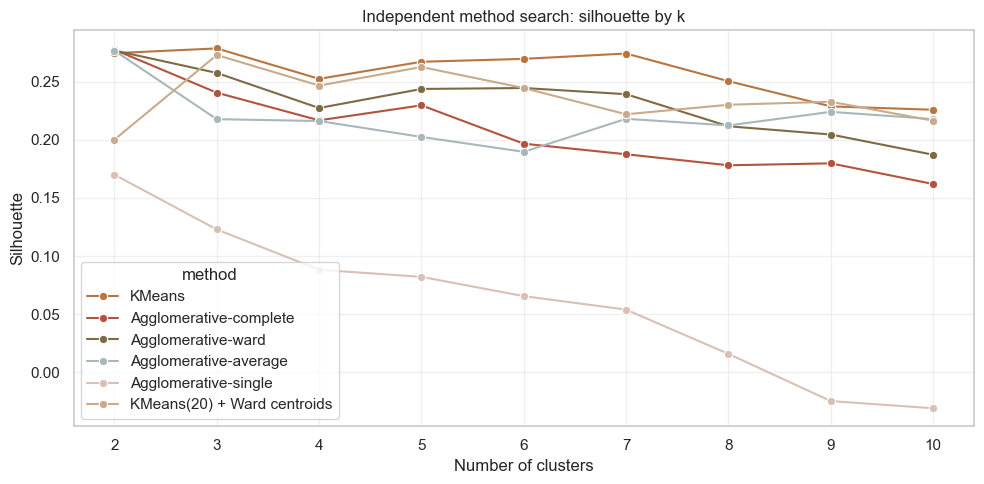

,method,k,silhouette,min_cluster_size,max_cluster_size,largest_share_%
0,KMeans,3,0.2787,7184,15681,48.9
1,Agglomerative-complete,2,0.2776,1118,3882,77.6
2,Agglomerative-ward,2,0.2769,1115,3885,77.7
3,Agglomerative-average,2,0.2768,1118,3882,77.6
4,KMeans,2,0.2746,7346,24710,77.1
5,KMeans,7,0.2743,3047,8477,26.4
6,KMeans(20) + Ward centroids,3,0.2730,6949,16122,50.3
7,KMeans(20) + Ward centroids,5,0.2627,2933,10048,31.3
8,KMeans(20) + Ward centroids,4,0.2467,6074,10048,31.3


KMeans candidates


,method,k,silhouette,min_cluster_size,max_cluster_size,largest_share_%
1,KMeans,3,0.2787,7184,15681,48.9
0,KMeans,2,0.2746,7346,24710,77.1
5,KMeans,7,0.2743,3047,8477,26.4
4,KMeans,6,0.2697,3016,8937,27.9
3,KMeans,5,0.2672,3015,8963,28.0


Best hierarchical candidates


,method,linkage,k,sample_size,silhouette,r2,min_cluster_size,max_cluster_size,largest_share_%
0,Agglomerative-complete,complete,2,5000,0.2776,0.2542,1118,3882,77.6
1,Agglomerative-ward,ward,2,5000,0.2769,0.2534,1115,3885,77.7
2,Agglomerative-average,average,2,5000,0.2768,0.2536,1118,3882,77.6
3,Agglomerative-ward,ward,3,5000,0.2576,0.4108,1115,2195,43.9
4,Agglomerative-ward,ward,6,5000,0.2446,0.5678,475,1690,33.8


Best centroid Ward candidates


,method,k,micro_k,silhouette,r2,min_cluster_size,max_cluster_size,largest_share_%
1,KMeans(20) + Ward centroids,3,20,0.2730,0.4315,6949,16122,50.3
3,KMeans(20) + Ward centroids,5,20,0.2627,0.5471,2933,10048,31.3
2,KMeans(20) + Ward centroids,4,20,0.2467,0.5063,6074,10048,31.3
4,KMeans(20) + Ward centroids,6,20,0.2446,0.5837,2933,8985,28.0
7,KMeans(20) + Ward centroids,9,20,0.2328,0.6657,974,6282,19.6


In [25]:
K_SEARCH_RANGE = range(2, 11)

method_benchmarks = uc.run_method_benchmarks(
    X,
    k_range=K_SEARCH_RANGE,
    random_state=0,
)

uc.display_method_benchmarks(method_benchmarks)

<div style="background-color:#7E6A43; color:#F3EEE6; padding:15px; border-radius:10px;">
<b>Benchmark interpretation.</b><br><br>
The benchmark table is intentionally separated by method family, because each algorithm reports a different set of diagnostics. KMeans is evaluated mainly through silhouette and cluster balance; hierarchical clustering adds a variance explained measure; centroid Ward uses an intermediate set of KMeans micro clusters. Keeping the tables separate avoids empty columns and makes the comparison easier to read.
<br><br>
The final model is not selected by the highest silhouette alone. A solution is only retained if it is also stable, visually coherent in the UMAP projection, reasonably balanced in size and interpretable when compared with the full customer profile.
</div>

In [26]:
ward_sample_idx, ward_labels = uc.fit_hierarchical_sample(
    X,
    K,
    sample_size=5000,
    linkage="ward",
    random_state=0,
)
display(uc.compare_solutions(
    kmeans.labels_[ward_sample_idx],
    ward_labels,
    name_a="KMeans",
    name_b="Ward",
))

,Ward 0,Ward 1,Ward 2,Ward 3,Ward 4,Ward 5,Ward 6,Ward 7
KMeans 0,158,5,282,3,4,0,2,44
KMeans 1,3,1,0,0,0,586,9,0
KMeans 2,904,2,1,21,8,1,1,58
KMeans 3,0,512,67,3,0,0,0,25
KMeans 4,4,0,0,0,0,12,504,0
KMeans 5,47,0,5,11,475,0,0,1
KMeans 6,75,178,10,7,0,0,0,495
KMeans 7,32,0,4,430,10,0,0,0


### 8.0.1 - UMAP comparison on the Ward sample

The Ward comparison is also checked visually using the same sampled customers. A single UMAP projection is computed for that sample and then coloured twice: first with the final KMeans labels and then with the Ward labels. This makes the visual comparison fair because the coordinates are identical and only the clustering assignment changes.

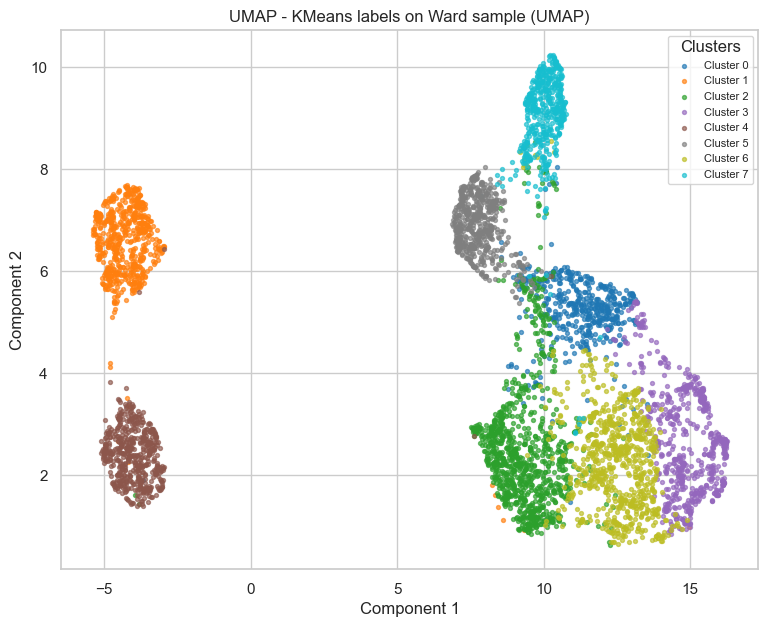

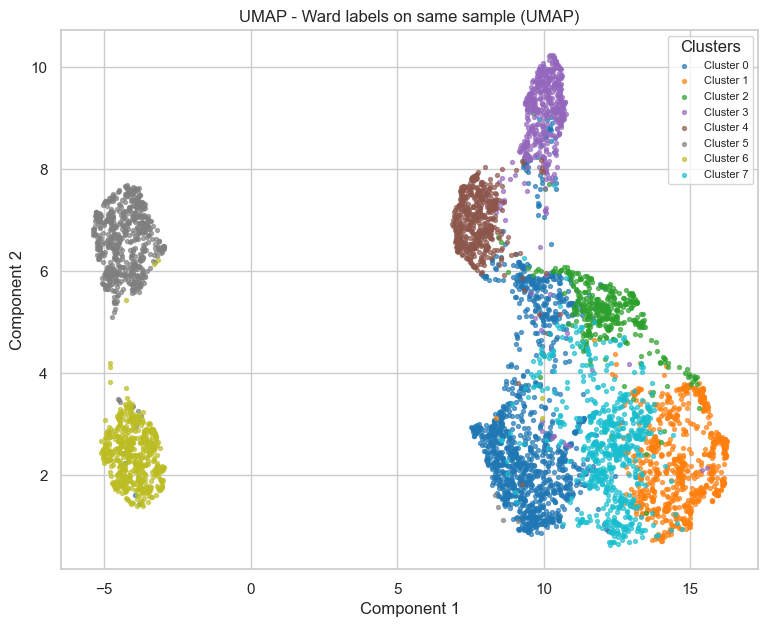

(array([[-3.8903222,  7.2868896],
        [12.16574  ,  5.4447856],
        [10.575861 ,  5.3228235],
        ...,
        [10.709256 ,  2.401857 ],
        [11.418965 ,  5.2347116],
        [10.461683 ,  9.160761 ]], shape=(5000, 2), dtype=float32),
 'UMAP')

In [27]:
uc.plot_umap_label_comparison(
    X[ward_sample_idx],
    kmeans.labels_[ward_sample_idx],
    ward_labels,
    title_a="UMAP - KMeans labels on Ward sample",
    title_b="UMAP - Ward labels on same sample",
    random_state=0,
)

### 8.1 - Ward, complete, average and single sample comparison

This fits agglomerative clustering on the same sample with four linkages. It does not replace the final KMeans model; it checks whether the broad structure is stable under different hierarchical assumptions.


In [28]:
hierarchical_comparison, hierarchical_solution_tables = uc.compare_hierarchical_linkages(
    X,
    K,
    kmeans.labels_,
    sample_size=5000,
    random_state=0,
)

display(hierarchical_comparison)

for linkage_name, comparison_table in hierarchical_solution_tables.items():
    print(f"KMeans vs Agglomerative-{linkage_name}")
    display(comparison_table)

,method,sample_size,k,silhouette_sample
0,Agglomerative-ward,5000,8,0.2117
1,Agglomerative-complete,5000,8,0.1781
2,Agglomerative-average,5000,8,0.2124
3,Agglomerative-single,5000,8,0.0158


KMeans vs Agglomerative-ward


,Ward 0,Ward 1,Ward 2,Ward 3,Ward 4,Ward 5,Ward 6,Ward 7
KMeans 0,158,5,282,3,4,0,2,44
KMeans 1,3,1,0,0,0,586,9,0
KMeans 2,904,2,1,21,8,1,1,58
KMeans 3,0,512,67,3,0,0,0,25
KMeans 4,4,0,0,0,0,12,504,0
KMeans 5,47,0,5,11,475,0,0,1
KMeans 6,75,178,10,7,0,0,0,495
KMeans 7,32,0,4,430,10,0,0,0


KMeans vs Agglomerative-complete


,Complete 0,Complete 1,Complete 2,Complete 3,Complete 4,Complete 5,Complete 6,Complete 7
KMeans 0,0,1,97,59,9,14,204,114
KMeans 1,596,0,1,2,0,0,0,0
KMeans 2,4,5,0,862,1,9,85,30
KMeans 3,0,1,543,0,0,0,63,0
KMeans 4,518,0,0,2,0,0,0,0
KMeans 5,0,9,0,61,434,0,0,35
KMeans 6,0,5,154,60,0,19,527,0
KMeans 7,0,405,0,51,2,1,13,4


KMeans vs Agglomerative-average


,Average 0,Average 1,Average 2,Average 3,Average 4,Average 5,Average 6,Average 7
KMeans 0,185,7,2,1,0,0,301,2
KMeans 1,2,0,0,596,0,0,1,0
KMeans 2,920,9,0,4,1,0,62,0
KMeans 3,0,0,0,0,0,1,606,0
KMeans 4,4,1,0,515,0,0,0,0
KMeans 5,48,485,2,0,3,0,1,0
KMeans 6,70,0,0,2,0,1,692,0
KMeans 7,463,8,0,0,0,1,4,0


KMeans vs Agglomerative-single


,Single 0,Single 1,Single 2,Single 3,Single 4,Single 5,Single 6,Single 7
KMeans 0,497,1,0,0,0,0,0,0
KMeans 1,599,0,0,0,0,0,0,0
KMeans 2,996,0,0,0,0,0,0,0
KMeans 3,605,0,0,0,0,1,1,0
KMeans 4,520,0,0,0,0,0,0,0
KMeans 5,537,0,1,0,1,0,0,0
KMeans 6,764,0,0,0,0,0,0,1
KMeans 7,475,0,0,1,0,0,0,0


### 8.1.1 - Benchmark label usage

<div style="background-color:#7E6A43; color:#F3EEE6; padding:15px; border-radius:10px;">
The final customer assignment remains the KMeans label stored in <code>cluster</code>. The other labels created in this section are used only for diagnostics: hierarchical labels compare the final model with alternative linkage assumptions, DBSCAN checks whether density based groups are plausible, and SOM units support visual profiling of the feature space.
<br><br>
This distinction is important because not every benchmark is fitted on the same scope. Direct hierarchical clustering is evaluated on a sample due to its computational cost, while the final KMeans model is fitted on the regular customer dataset and later used for the final export.
</div>


### 8.2 - Hierarchical R2 comparison

The R2-like metric compares how much of the total variance is explained by the cluster separation for each hierarchical linkage and number of clusters. It is used as an additional diagnostic alongside silhouette and dendrogram inspection.


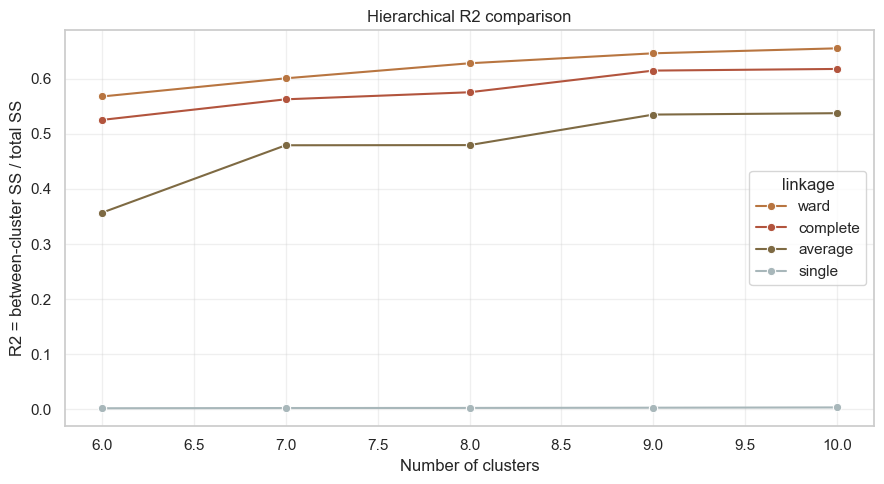

linkage,average,complete,single,ward
k,,,,
6,0.3569,0.5253,0.0021,0.5678
7,0.4793,0.5627,0.0025,0.6008
8,0.4796,0.5755,0.0027,0.6281
9,0.5350,0.6148,0.0031,0.6462
10,0.5375,0.6178,0.0036,0.6552


In [29]:
hierarchical_r2 = uc.hierarchical_r2_grid(
    X,
    k_range=range(6, 11),
    linkages=["ward", "complete", "average", "single"],
    sample_size=5000,
    random_state=0,
)

uc.plot_hierarchical_r2(hierarchical_r2)
display(hierarchical_r2.pivot(index="k", columns="linkage", values="r2"))


### 8.3 - Hierarchical on KMeans centroids
This benchmark uses a two stage strategy. First, <b>20 KMeans small clusters</b> are created to summarise the detailed structure of the customer space. Second, Ward hierarchical clustering groups those centroids into the final larger segments. Keeping <code>MICRO_K = 20</code> makes the intermediate representation granular enough to reveal local structure, while still small enough to inspect with a dendrogram.


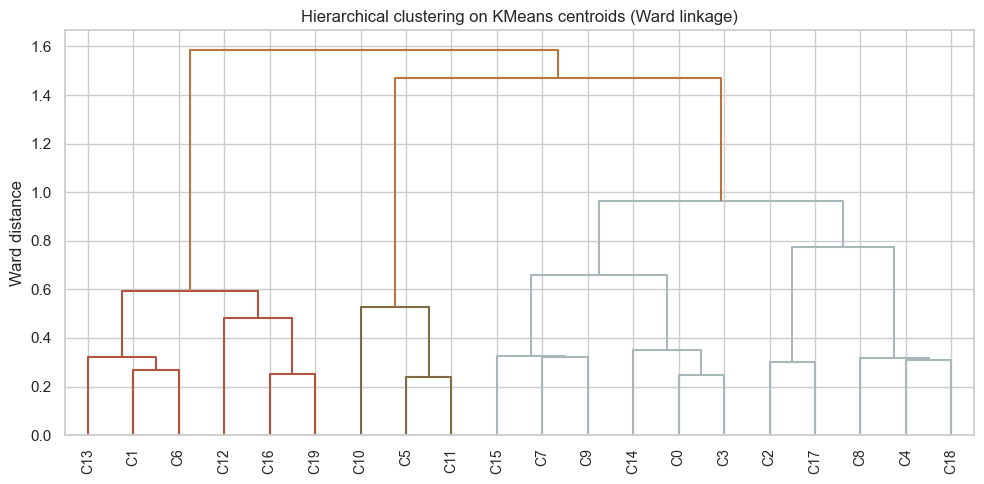

Micro-cluster sizes


micro_cluster
0     2433
1     1759
2     1663
3     2073
4     1073
5     1694
6     1824
7     1278
8      971
9     1218
10    3649
11    1606
12     974
13    1299
14    1776
15    1270
16    1543
17    1478
18     889
19    1586
Name: count, dtype: int64

Macro-cluster sizes


macro_cluster
0    4882
1    4103
2    3300
3    3649
4    3766
5    6282
6    3141
7    2933
Name: count, dtype: int64

,solution,silhouette
0,Final KMeans,0.2508
1,Centroid Ward macro,0.2305


In [30]:
MICRO_K = 20
micro_kmeans, centroids_df, Z = uc.apply_centroid_ward_macro(
    regular,
    X,
    distance_cols,
    K,
    micro_k=MICRO_K,
    random_state=0,
)

,Centroid Ward macro 0,Centroid Ward macro 1,Centroid Ward macro 2,Centroid Ward macro 3,Centroid Ward macro 4,Centroid Ward macro 5,Centroid Ward macro 6,Centroid Ward macro 7
Final KMeans 0,63,595,0,0,2561,6,13,23
Final KMeans 1,3,0,49,3645,0,17,0,1
Final KMeans 2,193,0,0,1,697,5312,86,4
Final KMeans 3,694,3500,0,0,3,0,0,0
Final KMeans 4,1,0,3251,3,8,1,0,0
Final KMeans 5,0,0,0,0,327,1,64,2896
Final KMeans 6,3926,8,0,0,129,923,37,1
Final KMeans 7,2,0,0,0,41,22,2941,8


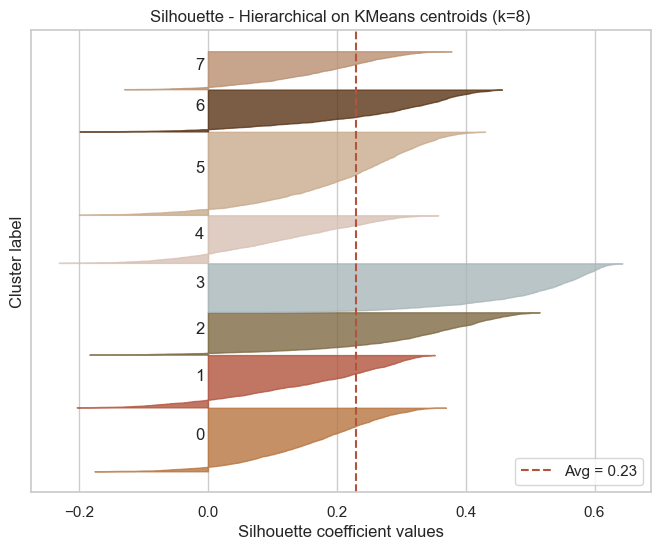

0.2291919279481265

In [31]:
macro_comparison = uc.compare_solutions(
    regular["cluster"].values,
    regular["macro_cluster"].values,
    name_a="Final KMeans",
    name_b="Centroid Ward macro",
)
display(macro_comparison)

uc.plot_silhouette_blades(
    X,
    regular["macro_cluster"].values,
    title=f"Silhouette - Hierarchical on KMeans centroids (k={K})",
)

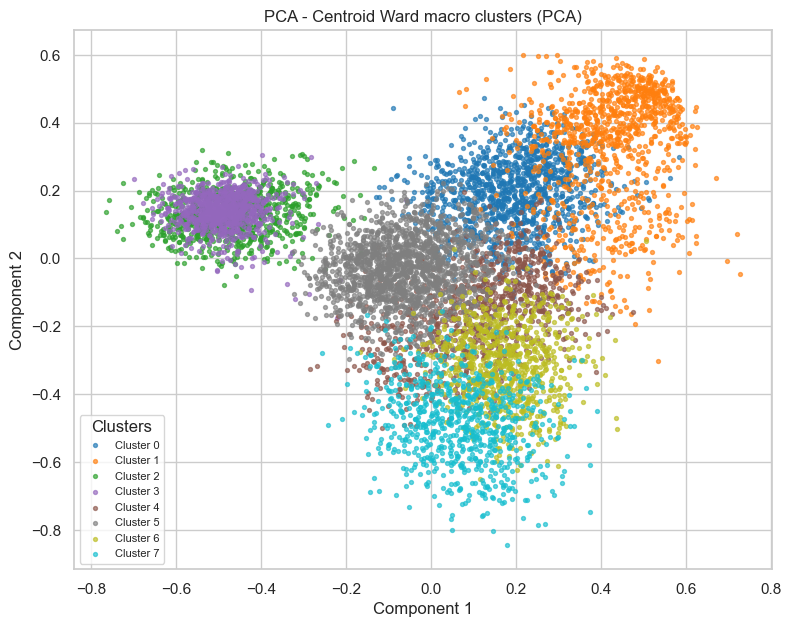

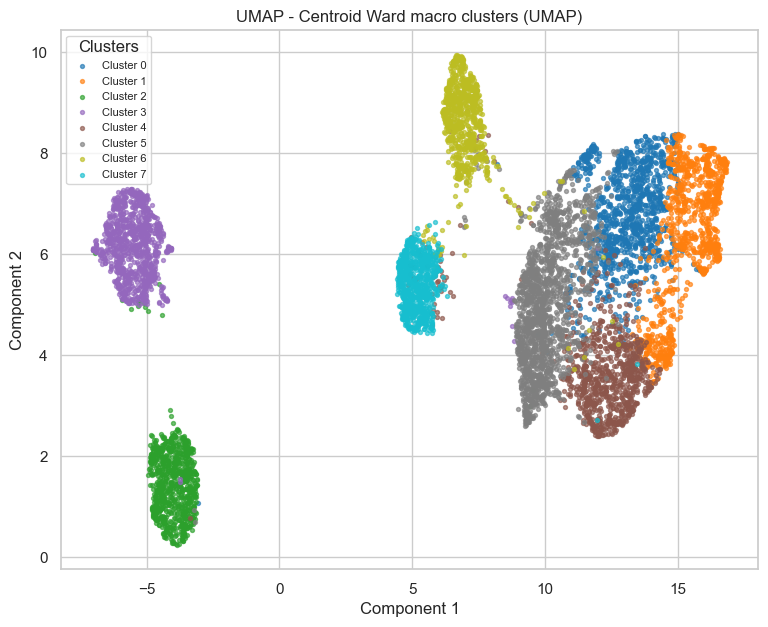

In [32]:
uc.plot_macro_embeddings(
    X,
    regular["macro_cluster"].values,
    sample_size=8000,
    random_state=0,
)

### 8.4 - DBSCAN density benchmark

DBSCAN is used as a density based benchmark. The parameter grid includes small and moderate `eps` values because the final matrix is MinMax scaled. Very small `eps` values tend to classify most customers as noise, while large values tend to merge almost everyone into one cluster. For this reason, the table is read in two steps: first by checking the best valid silhouettes, and then by filtering for candidates with a manageable noise share. This avoids selecting a visually impressive silhouette that only describes a very small non noise subset of customers.

In [33]:
dbscan_results, valid_dbscan, invalid_dbscan = uc.dbscan_benchmark_table(
    X,
    eps_values=[0.03, 0.04, 0.05, 0.06, 0.07, 0.08, 0.09, 0.10,
                0.12, 0.14, 0.16, 0.18, 0.20, 0.25, 0.30, 0.35, 0.40],
    min_samples_values=[3, 5, 8, 10, 15, 20, 30, 40],
    sample_size=8000,
    random_state=0,
)

practical_dbscan = uc.practical_dbscan_candidates(
    dbscan_results,
    min_clusters=2,
    max_clusters=12,
    max_noise_pct=35,
)

print("Best valid DBSCAN settings by silhouette")
display(valid_dbscan.head(10))

print("Practical DBSCAN candidates after limiting the noise share")
display(practical_dbscan.head(10))

print("Parameter settings with one cluster or no valid silhouette")
display(invalid_dbscan.head(10))

Best valid DBSCAN settings by silhouette


,eps,min_samples,n_clusters,noise_pct,silhouette_non_noise
0,0.09,8,2,93.41,0.8251
1,0.10,10,3,91.40,0.7492
2,0.12,20,3,89.55,0.7278
3,0.14,40,3,88.35,0.6979
4,0.06,5,2,99.62,0.4994
5,0.10,8,9,90.26,0.4764
6,0.14,30,6,83.15,0.4709
7,0.05,3,3,99.89,0.4706
8,0.16,40,3,70.95,0.4403
9,0.14,15,3,70.93,0.4280


Practical DBSCAN candidates after limiting the noise share


,eps,min_samples,n_clusters,noise_pct,silhouette_non_noise
0,0.18,8,2,33.07,0.3543
1,0.20,20,2,31.24,0.3536
2,0.20,15,2,27.89,0.3459
3,0.20,10,3,23.57,0.2791
4,0.20,8,5,21.22,0.2246
5,0.25,5,2,3.34,0.0568
6,0.25,3,2,2.61,-0.0165
7,0.20,5,6,16.49,-0.0555


Parameter settings with one cluster or no valid silhouette


,eps,min_samples,n_clusters,noise_pct
0,0.40,3,1,0.01
1,0.40,5,1,0.03
2,0.40,8,1,0.03
3,0.40,10,1,0.03
4,0.40,15,1,0.03
5,0.40,20,1,0.03
6,0.40,30,1,0.04
7,0.40,40,1,0.04
8,0.35,3,1,0.11
9,0.35,5,1,0.12


**DBSCAN interpretation after parameter tuning.**

The tuned grid produces valid DBSCAN solutions, but the strongest silhouettes are obtained when most customers are classified as noise. After restricting the noise share, DBSCAN still produces only a small number of broad density groups and does not recover the richer eight segment structure obtained with KMeans. Therefore, DBSCAN is kept as a benchmark: it confirms that the customer space does not contain clearly separated density islands, while the final KMeans model remains more appropriate for compact and interpretable customer segmentation.

In [34]:
RUN_DBSCAN = False
DBSCAN_EPS = 0.9
DBSCAN_MIN_SAMPLES = 10

dbscan_labels = uc.maybe_fit_dbscan(
    X,
    run=RUN_DBSCAN,
    eps=DBSCAN_EPS,
    min_samples=DBSCAN_MIN_SAMPLES,
)

if dbscan_labels is not None:
    regular["dbscan_cluster"] = dbscan_labels

DBSCAN is kept as a benchmark only. The final assignment is not based on DBSCAN labels.


### 8.5 - SOM Map feature map analysis

A SOM Map is used as an exploratory validation tool rather than as the final clustering algorithm. A medium sized grid is used so that neighbourhood patterns remain visible without creating hundreds of almost empty units. The hit map shows where customers concentrate, the U Matrix highlights stronger separations between neighbouring units, and the feature maps show how the main variables vary across the same customer space.

Running SOM hyperparameter grid search …


,sigma,learning_rate,quantization_error,topographic_error,combined_score
0,2.0,0.5,0.3195,0.0784,0.3979
1,2.0,0.3,0.3274,0.0965,0.4239
2,2.0,0.7,0.3225,0.1124,0.4348
3,1.5,0.7,0.3087,0.1660,0.4747
4,2.0,0.9,0.3233,0.1540,0.4773
5,1.5,0.3,0.3155,0.1755,0.4910
6,1.5,0.9,0.3089,0.1914,0.5002
7,1.5,0.5,0.3120,0.1973,0.5092
8,1.0,0.7,0.3040,0.4027,0.7067
9,1.0,0.5,0.3039,0.4400,0.7439


Best params → sigma=2.0, learning_rate=0.5


,iteration,quantization_error
0,50,0.3595
1,100,0.3787
2,200,0.3817
3,400,0.3524
4,700,0.3407
5,1000,0.3394


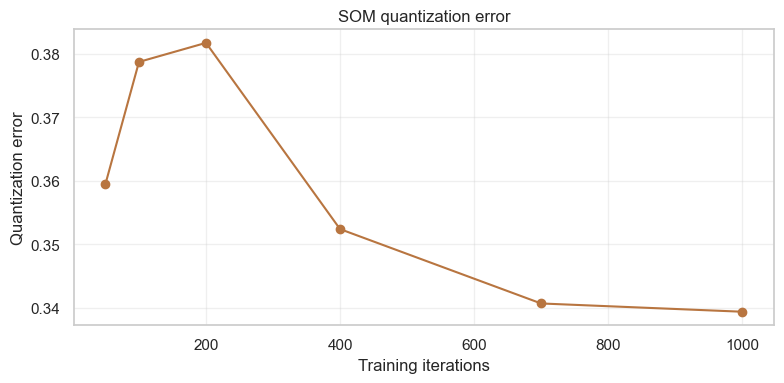

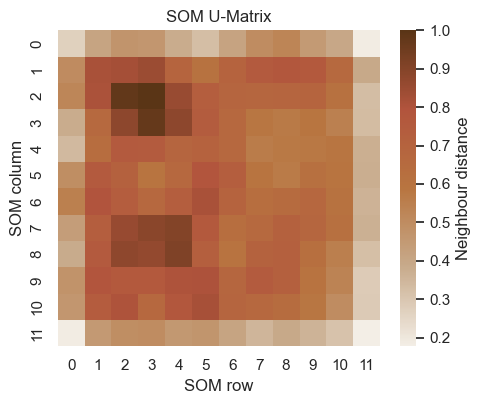

In [35]:
SOM_GRID = (12, 12)
SOM_ITERATIONS = 1000

som_cols, X_som, som_curve, som_model = uc.run_som_diagnostic(
    regular,
    scaler_name=SCALER,
    grid=SOM_GRID,
    iterations=SOM_ITERATIONS,
    sample_size=12000,
    random_state=0,
)

Active SOM units: 143 out of 144


,customers
12,909
0,903
96,678
48,629
120,532
140,526
7,519
45,470
3,462
2,442


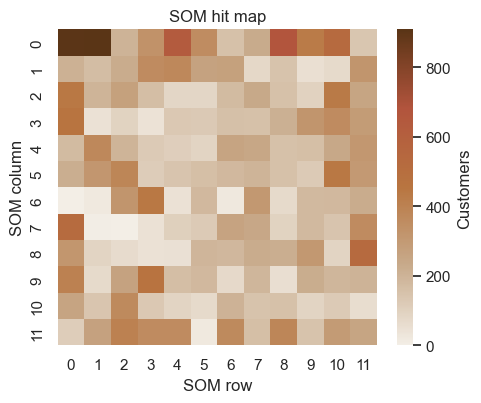

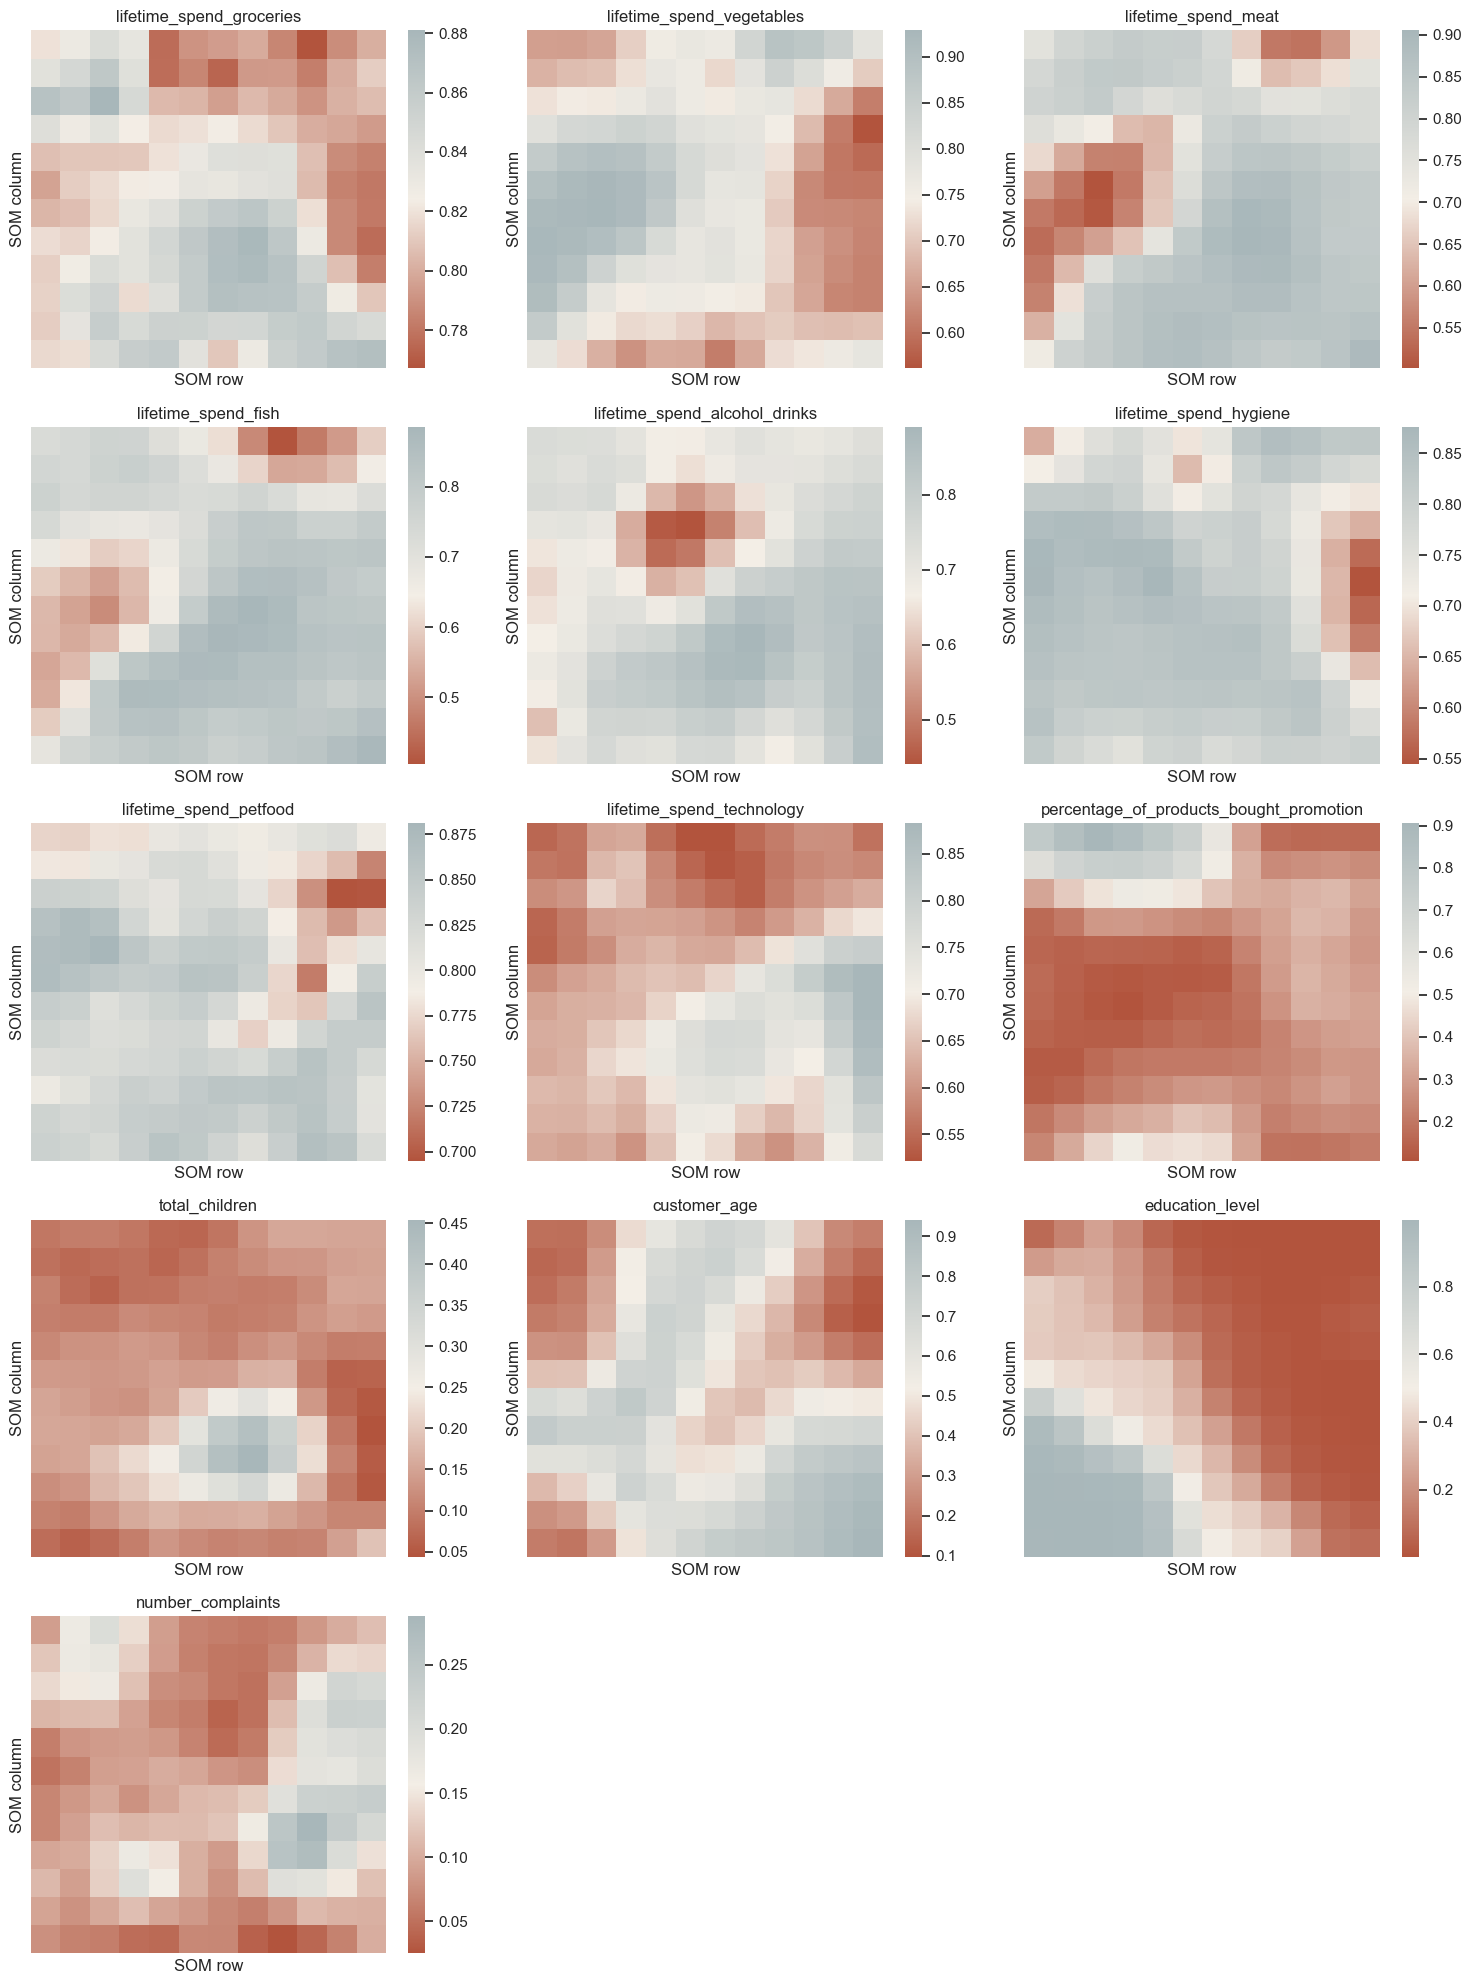

In [36]:
regular["som_unit"] = uc.assign_and_plot_som(
    regular,
    som_model,
    X_som,
    som_cols,
    grid=SOM_GRID,
)

### 8.5.1 - SOM interpretation

The SOM is used as visual support for the final segmentation. It helps check whether related variables occupy coherent regions of the same customer map.

The main aspects inspected are vegetables and hygiene for the wellness profile, technology for the technology oriented segment, promotion usage for the discount oriented segment, household variables for the family segment and complaints for service sensitivity.

Because the SOM does not optimise the same objective as KMeans, it is not used to assign final labels. It remains an exploratory diagnostic that supports the profiling stage.

<div style="background-color:#5A3516; color:#F3EEE6; padding:20px; border-radius:10px; border-left:8px solid #A8B7BA;">
<h2 style="color:#F3EEE6; margin:0;"><b>9) Segment profiling</b></h2>
<p style="color:#D8C0B4; margin:6px 0 0 0;">The clustering model gives numerical labels, but the business value comes from understanding what those labels represent. This section compares the clusters using spending, demographic, engagement, location and complaint variables. The goal is to name the segments from repeated evidence, not from a single high value in one column.</p>
</div>


<div style="background-color:#7E6A43; color:#F3EEE6; padding:15px; border-radius:10px;">
<b>From labels to business meaning.</b><br><br>
At this stage the question changes from “are the points separated?” to “what type of customer does each group represent?”. For that reason, the profiling stage uses more variables than the clustering distance. This is not inconsistent: the model is fitted on a clean distance space, and the full customer information is then used to interpret the resulting groups.
</div>

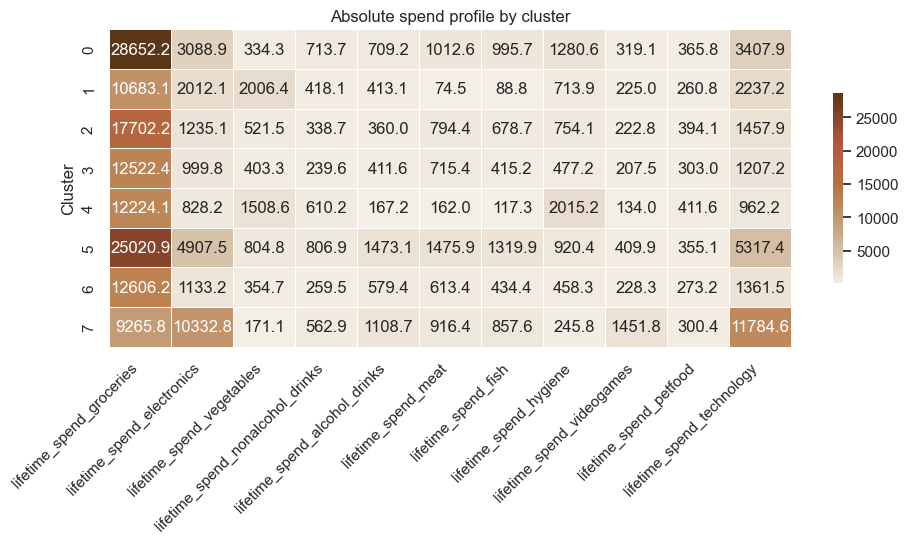

,lifetime_spend_groceries,lifetime_spend_electronics,lifetime_spend_vegetables,lifetime_spend_nonalcohol_drinks,lifetime_spend_alcohol_drinks,lifetime_spend_meat,lifetime_spend_fish,lifetime_spend_hygiene,lifetime_spend_videogames,lifetime_spend_petfood,lifetime_spend_technology
cluster,,,,,,,,,,,
0,28652.19,3088.88,334.29,713.67,709.23,1012.62,995.69,1280.61,319.05,365.81,3407.93
1,10683.12,2012.14,2006.37,418.13,413.10,74.48,88.83,713.92,225.02,260.76,2237.15
2,17702.21,1235.13,521.50,338.73,359.96,794.39,678.70,754.09,222.78,394.08,1457.91
3,12522.39,999.77,403.32,239.60,411.65,715.35,415.19,477.22,207.49,302.98,1207.25
4,12224.10,828.24,1508.63,610.23,167.16,162.00,117.27,2015.23,133.96,411.55,962.20
5,25020.86,4907.46,804.75,806.94,1473.09,1475.91,1319.89,920.37,409.94,355.09,5317.39
6,12606.24,1133.18,354.69,259.46,579.43,613.39,434.43,458.26,228.30,273.19,1361.48
7,9265.79,10332.81,171.06,562.87,1108.69,916.37,857.58,245.79,1451.76,300.37,11784.57
OVERALL,15925.51,2657.60,729.54,457.41,607.75,711.43,595.22,818.06,357.40,333.85,3015.00


In [37]:
spend_cols = [c for c in regular.columns if c.startswith('lifetime_spend_')]
spend_profile = uc.profile_clusters(regular, 'cluster', spend_cols)
uc.plot_profile_heatmap(spend_profile, 'Absolute spend profile by cluster')
spend_profile


### 9.1 - Petfood signal check in the current model

Petfood spending is reviewed in the current model profile because one alternative solution explicitly includes this category. In this section the check is based only on absolute spend, keeping the interpretation consistent with the lifetime spend logic used in the clustering distance.


In [38]:
if "lifetime_spend_petfood" in spend_profile.columns:
    pet_check = spend_profile.drop(index="OVERALL", errors="ignore").copy()
    pet_check = pet_check[["lifetime_spend_petfood"]].round(2)
    display(pet_check.sort_values("lifetime_spend_petfood", ascending=False))

    print("Highest absolute petfood cluster:", pet_check["lifetime_spend_petfood"].idxmax())


,lifetime_spend_petfood
cluster,
4,411.55
2,394.08
0,365.81
5,355.09
3,302.98
7,300.37
6,273.19
1,260.76


Highest absolute petfood cluster: 4


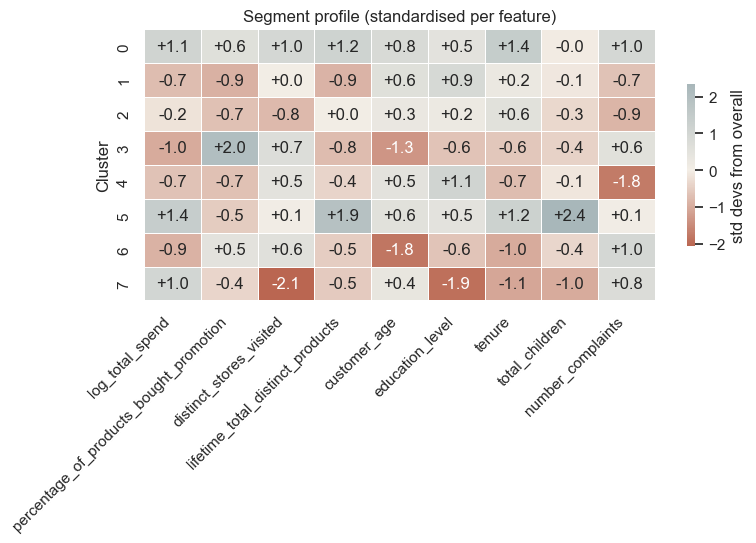

,log_total_spend,percentage_of_products_bought_promotion,distinct_stores_visited,lifetime_total_distinct_products,customer_age,education_level,tenure,total_children,number_complaints
cluster,,,,,,,,,
0,1.09,0.62,0.98,1.15,0.85,0.49,1.42,-0.04,0.95
1,-0.73,-0.92,0.03,-0.88,0.62,0.89,0.25,-0.09,-0.67
2,-0.18,-0.68,-0.80,0.03,0.28,0.23,0.57,-0.33,-0.87
3,-1.01,2.04,0.70,-0.77,-1.35,-0.65,-0.60,-0.43,0.56
4,-0.66,-0.68,0.49,-0.38,0.49,1.09,-0.74,-0.11,-1.76
5,1.39,-0.52,0.07,1.90,0.56,0.50,1.21,2.36,0.07
6,-0.91,0.50,0.60,-0.51,-1.82,-0.63,-1.01,-0.36,0.95
7,1.01,-0.37,-2.07,-0.54,0.36,-1.92,-1.09,-1.01,0.76


In [39]:
key_cols = [c for c in [
    "log_total_spend", "percentage_of_products_bought_promotion",
    "distinct_stores_visited", "lifetime_total_distinct_products",
    "customer_age", "education_level", "tenure", "total_children",
    "number_complaints",
] if c in regular.columns]

mixed_profile = uc.profile_clusters(regular, "cluster", key_cols)
uc.plot_profile_heatmap_z(mixed_profile,
                          title="Segment profile (standardised per feature)")

### 9.2 - Segment separation plots

The following plots summarise the same profiling logic in a more visual way. The scaled mean comparison highlights which clusters are highest or lowest on each variable, while the boxplots show whether the separation is concentrated around the median or driven mainly by extreme customers.


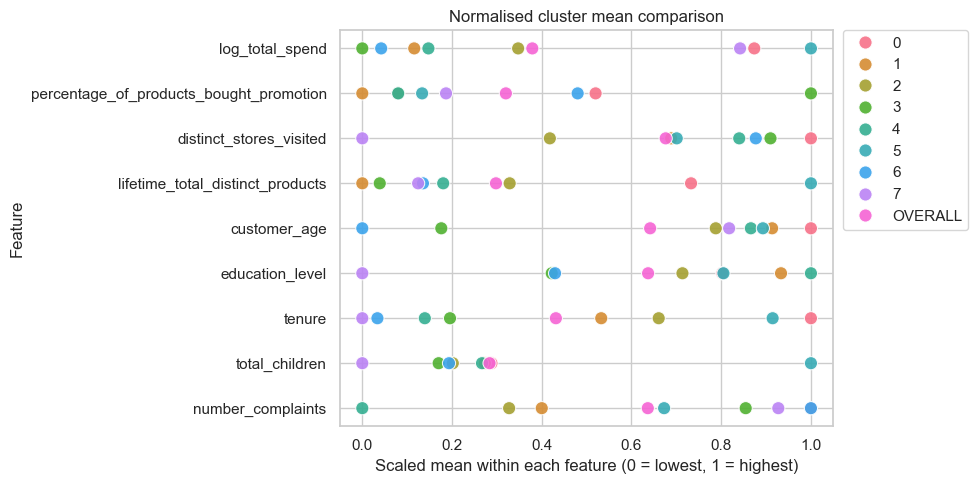

,log_total_spend,percentage_of_products_bought_promotion,distinct_stores_visited,lifetime_total_distinct_products,customer_age,education_level,tenure,total_children,number_complaints
cluster,,,,,,,,,
0,0.87,0.52,1.00,0.73,1.00,0.80,1.00,0.29,1.00
1,0.12,0.00,0.69,0.00,0.91,0.93,0.53,0.27,0.40
2,0.35,0.08,0.42,0.33,0.79,0.71,0.66,0.20,0.33
3,0.00,1.00,0.91,0.04,0.18,0.42,0.20,0.17,0.85
4,0.15,0.08,0.84,0.18,0.87,1.00,0.14,0.27,0.00
5,1.00,0.13,0.70,1.00,0.89,0.80,0.91,1.00,0.67
6,0.04,0.48,0.88,0.14,0.00,0.43,0.03,0.19,1.00
7,0.84,0.19,0.00,0.12,0.82,0.00,0.00,0.00,0.93
OVERALL,0.38,0.32,0.68,0.30,0.64,0.64,0.43,0.28,0.64


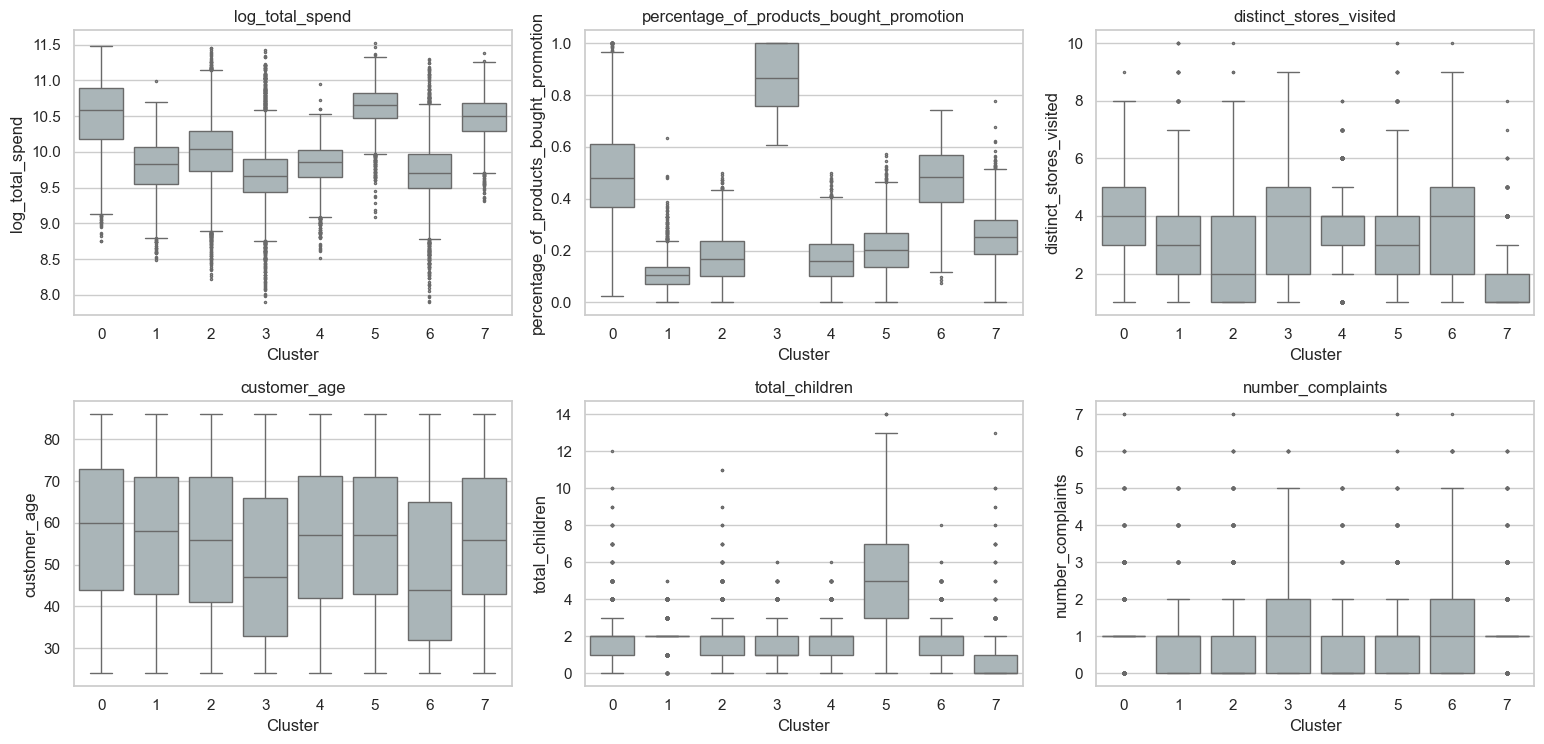

In [40]:
scaled_profile = uc.plot_segment_separation(
    regular,
    label_col="cluster",
)

### 9.3 - Complaint behaviour by segment

Complaint behaviour is reviewed separately because it can support the interpretation of segments with higher service sensitivity or dissatisfaction risk.


In [41]:
complaints_profile = uc.complaint_summary(
    regular,
    label_col="cluster",
    complaint_col="number_complaints",
    threshold=2,
)
display(complaints_profile)


,customers,avg_complaints,pct_complaints_ge_2,max_complaints
cluster,,,,
0,3261,1.11,20.1,7
1,3715,0.78,7.7,5
2,6293,0.74,16.4,7
3,4197,1.03,29.1,6
4,3264,0.56,3.1,5
5,3288,0.93,19.7,7
6,5024,1.11,34.7,7
7,3014,1.07,24.3,6


### 9.4 - Geographic profiling

Geographic variables are used only after clustering, as profiling variables. They are not included in the clustering distance because location could dominate the segmentation and create geographic groups instead of behavioural customer segments.

The scatter plot provides a first visual check of whether any segment is spatially concentrated. Because most customers are located in a dense Lisbon area rectangle, overlap is expected. The purpose of this section is therefore not to define clusters geographically, but to identify whether any segment has a noticeable location pattern that can support interpretation or business actions.


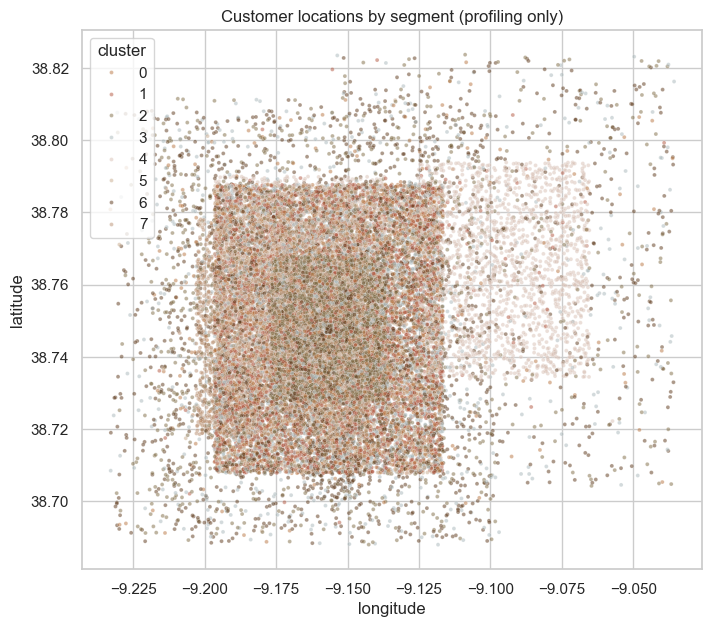

In [42]:
if {'latitude','longitude'}.issubset(regular.columns):
    plt.figure(figsize=(8, 7))
    sns.scatterplot(data=regular, x='longitude', y='latitude',
                    hue='cluster', palette=['#B87540', '#B2543D', '#7E6A43', '#A8B7BA', '#D8C0B4', '#C8AB8C', '#5A3516', '#B98F70'], s=8, alpha=0.5, legend='full')
    plt.title('Customer locations by segment (profiling only)')
    plt.show()

,customers,mean_latitude,mean_longitude,median_latitude,median_longitude,latitude_std,longitude_std
cluster,,,,,,,
0,3261,38.74869,-9.15607,38.74795,-9.15621,0.02377,0.02530
1,3715,38.74781,-9.15632,38.74749,-9.15660,0.02310,0.02410
2,6293,38.74865,-9.15615,38.74793,-9.15672,0.02003,0.02369
3,4197,38.74788,-9.15498,38.74766,-9.15660,0.02361,0.02665
4,3264,38.76227,-9.12961,38.76209,-9.12351,0.01753,0.03958
5,3288,38.74828,-9.15714,38.74856,-9.15726,0.02336,0.02338
6,5024,38.74835,-9.15337,38.74774,-9.15647,0.02535,0.03048
7,3014,38.74832,-9.17209,38.74896,-9.17189,0.01763,0.01795


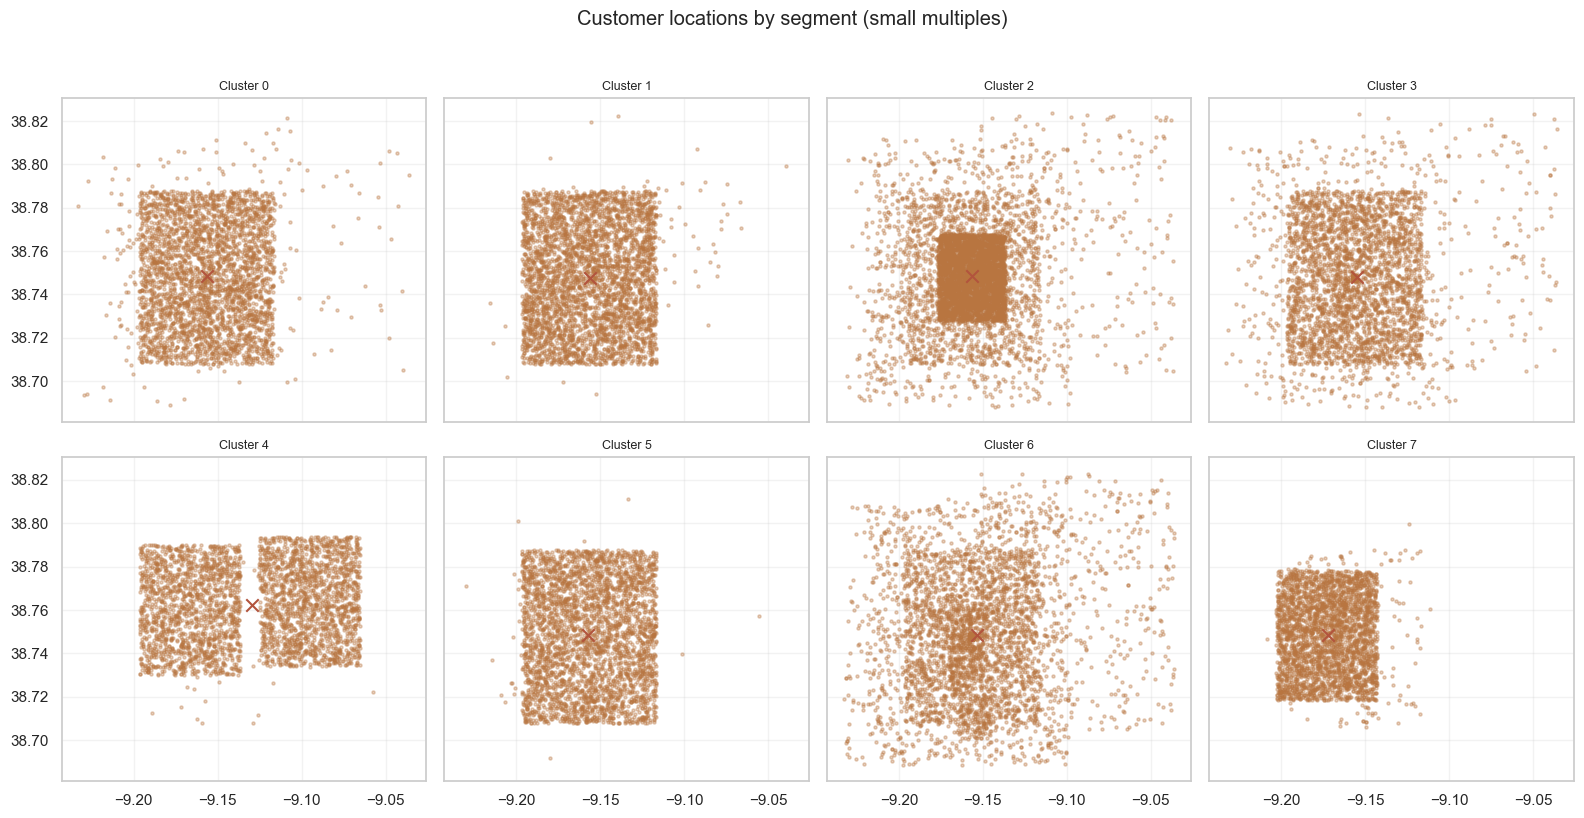

In [43]:
geo_profile = uc.geographic_profile(
    regular,
    label_col="cluster",
)

<div style="background-color:#7E6A43; color:#F3EEE6; padding:15px; border-radius:10px;">
<b>Geographic interpretation.</b><br><br>
The geographic plot should be interpreted cautiously. A strong overlap between colours means that the final clusters are mainly behavioural rather than geographic, which is desirable because latitude and longitude were intentionally excluded from the clustering distance. If one segment appears more concentrated in a specific area, this can be reported as a profiling insight, but it should not be treated as the main reason for the segment definition.
<br><br>
In practical terms, this analysis can support local marketing decisions, store level planning or regional campaign targeting. However, the final segment names remain based on spending, promotion behaviour, demographic profile and customer behaviour rather than location alone.
</div>


### 9.5 - Numeric cluster labels

The modelling stage keeps the final groups as numeric labels. Business names are assigned in the characterization stage, after the numerical labels are compared with spend, demographic, loyalty and complaint profiles.

In [44]:
cluster_labels = pd.DataFrame({
    "cluster": sorted(regular["cluster"].unique())
})
display(cluster_labels)


,cluster
0,0
1,1
2,2
3,3
4,4
5,5
6,6
7,7


<div style="background-color:#5A3516; color:#F3EEE6; padding:20px; border-radius:10px; border-left:8px solid #A8B7BA;">
<h2 style="color:#F3EEE6; margin:0;"><b>10) Reattach outliers and export</b></h2>
<p style="color:#D8C0B4; margin:6px 0 0 0;">The outlier subset is reattached only after the model is fitted. This preserves the influence of regular customers when learning the centroids, while still assigning a segment to every customer in the final export.</p>
</div>


In [45]:
segments = uc.reattach_outliers_and_export(
    regular,
    outliers,
    kmeans,
    distance_cols,
    LOGABS,
    scaler,
    DATA_DIR,
    spend_profile=spend_profile,
    complaints_profile=complaints_profile if "complaints_profile" in locals() else None,
)

Outliers assigned: 982
Customers in final file: 33038
cluster
0    3394
1    3740
2    6364
3    4295
4    3323
5    3663
6    5061
7    3198
Name: count, dtype: int64
Saved customer_segments.csv (+ supporting profiles) to ../datasets


In [46]:
segments.head()

,customer_id,cluster
0,3,6
1,4,4
2,5,2
3,7,7
4,8,7


<div style="background-color:#7E6A43; color:#F3EEE6; padding:15px; border-radius:10px;">
<code>customer_segments.csv</code> is the required deliverable, containing one final numeric segment assignment per customer. The additional exports support interpretation: <code>segment_summary.csv</code> gives segment sizes, <code>segment_spend_profile.csv</code> supports spend profiling, and <code>segment_complaints_profile.csv</code> highlights service sensitivity. Business names are assigned in the characterization stage.
</div>

<div style="background-color:#5A3516; color:#F3EEE6; padding:20px; border-radius:10px; border-left:8px solid #A8B7BA;">
<h2 style="color:#F3EEE6; margin:0;"><b>11) Final modelling conclusion</b></h2>
</div>

The final exported segmentation uses KMeans with `k = 8`, the `spend + promo no groceries` feature set and MinMax scaling. This solution is preferred because it gives the best overall compromise between metric quality, visual separation, cluster size balance and business interpretation.

The choice of `k = 8` is especially important. A smaller solution is simpler, but it merges customer profiles that are useful to keep apart. A larger solution creates additional detail, but the interpretation becomes less stable and less useful for reporting. Eight clusters keep the segmentation within a manageable range while preserving distinct groups such as loyal customers, promotion driven customers, families, wellness oriented customers, vegetarians, economizers and Techies.

The petfood alternative was deliberately tested because a pet oriented group would be useful from a business perspective. That model created a readable pet segment, but its overall geometric structure was slightly weaker. For this reason, petfood is kept as a profiling and campaign variable rather than as a final distance feature.

Overall, the final model is not presented as the solution with the highest single score. It is presented as the most defensible segmentation after comparing preprocessing choices, feature spaces, scalers, values of `k` and alternative clustering methods.

In [ ]:
decision_log = pd.DataFrame({
    "parameter": ["Feature set", "Scaler", "k", "Log-abs transform"],
    "value":     [FEATURE_SET,   SCALER,   K,   LOGABS],
}).set_index("parameter")

metrics_log = pd.DataFrame({
    "metric": ["Silhouette"],
    "value":  [round(avg_sil, 4)],
}).set_index("metric")

display(decision_log)
display(metrics_log)